In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

fintech_path = "/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech.csv"

df_fintech = pd.read_csv(fintech_path)

print("FinTech Dataset Loaded Successfully!")
print("Shape:", df_fintech.shape)

df_fintech.head()


FinTech Dataset Loaded Successfully!
Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [ ]:
import os
import random
import json
import joblib
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from xgboost import XGBClassifier
from PyPDF2 import PdfMerger

# ========= SETTINGS ==========
SEED = 11
DATA = df_fintech   # already loaded
RESULTS_ROOT = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized"
os.makedirs(RESULTS_ROOT, exist_ok=True)

# ========= SET GLOBAL SEED ==========
def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

set_global_seed(SEED)

# ========= PREPROCESSING ==========
target_col = "isFraud"  # this is your fraud label

X = DATA.drop(columns=[target_col])
y = DATA[target_col]

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

# ========= TRAIN / TEST SPLIT ==========
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Test Set:", X_test.shape)
print("Split completed successfully for seed =", SEED)


ModuleNotFoundError: No module named 'PyPDF2'

In [ ]:
!pip install PyPDF2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 9.6 MB/s eta 0:00:00


In [ ]:
import os
import random
import json
import joblib
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from xgboost import XGBClassifier
from PyPDF2 import PdfMerger

# ========= SETTINGS ==========
SEED = 11
DATA = df_fintech   # already loaded
RESULTS_ROOT = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized"
os.makedirs(RESULTS_ROOT, exist_ok=True)

# ========= SET GLOBAL SEED ==========
def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

set_global_seed(SEED)

# ========= PREPROCESSING ==========
target_col = "isFraud"

X = DATA.drop(columns=[target_col])
y = DATA[target_col]

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

# ========= TRAIN / TEST SPLIT ==========
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Test Set:", X_test.shape)
print("Split completed successfully for seed =", SEED)


TypeError: OneHotEncoder.__init__() got an unexpected keyword argument 'sparse'

In [ ]:
import os
import random
import json
import joblib
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from xgboost import XGBClassifier
from PyPDF2 import PdfMerger

# ========= SETTINGS ==========
SEED = 11
DATA = df_fintech   # already loaded
RESULTS_ROOT = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized"
os.makedirs(RESULTS_ROOT, exist_ok=True)

# ========= SET GLOBAL SEED ==========
def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

set_global_seed(SEED)

# ========= PREPROCESSING ==========
target_col = "isFraud"

X = DATA.drop(columns=[target_col])
y = DATA[target_col]

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

# ========= TRAIN / TEST SPLIT ==========
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Test Set:", X_test.shape)
print("Split completed successfully for seed =", SEED)


Training Set: (5090096, 10)
Test Set: (1272524, 10)
Split completed successfully for seed = 11


In [ ]:
# ===== Logistic Regression — Centralized FinTech (Seed = 11) =====

model_name = "lr"
out_dir = f"{RESULTS_ROOT}/seed_{SEED}/{model_name}"
os.makedirs(out_dir, exist_ok=True)

# Create model with reproducible seed
lr_model = LogisticRegression(
    solver="saga",
    max_iter=5000,
    random_state=SEED,
    n_jobs=-1
)

# Full pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lr_model)
])

print("Training Logistic Regression (seed = 11)...")
lr_pipeline.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)

# Compute metrics
metrics_lr = {
    "model": "Logistic Regression",
    "seed": SEED,
    "accuracy": float(accuracy_score(y_test, y_pred_lr)),
    "precision": float(precision_score(y_test, y_pred_lr, zero_division=0)),
    "recall": float(recall_score(y_test, y_pred_lr, zero_division=0)),
    "f1": float(f1_score(y_test, y_pred_lr, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test, y_prob_lr[:, 1]))
}

# Save metrics.json
with open(f"{out_dir}/metrics.json", "w") as f:
    json.dump(metrics_lr, f, indent=4)

# Save model
joblib.dump(lr_pipeline, f"{out_dir}/model.joblib")

# Classification report
report_lr = classification_report(y_test, y_pred_lr, zero_division=0)
with open(f"{out_dir}/report.txt", "w") as f:
    f.write(report_lr)

# Confusion matrix image
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.colorbar()
plt.tight_layout()
plt.savefig(f"{out_dir}/confusion.png")
plt.close()

# PDF report
pdf_path = f"{out_dir}/model_report.pdf"
with PdfPages(pdf_path) as pdf:
    fig = plt.figure(figsize=(8.27, 11.69))
    plt.text(0.01, 0.99, f"Model: Logistic Regression\nSeed: {SEED}\n\nMetrics:\n{json.dumps(metrics_lr, indent=4)}\n\nClassification Report:\n{report_lr}",
             ha='left', va='top', fontsize=10, family='monospace')
    plt.axis("off")
    pdf.savefig(fig)
    plt.close()

print(f"LR Completed. Files saved in: {out_dir}")


Training Logistic Regression (seed = 11)...


MemoryError: Unable to allocate 272. TiB for an array with shape (5090096, 7350609) and data type float64

In [ ]:
import os
import random
import json
import joblib
import numpy as np
import pandas as pd
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from xgboost import XGBClassifier
from PyPDF2 import PdfMerger

# ========= SETTINGS ==========
SEED = 11
DATA = df_fintech.copy()
RESULTS_ROOT = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized"
os.makedirs(RESULTS_ROOT, exist_ok=True)

# ========= DROP HIGH CARDINALITY ID COLUMNS ==========
DROP_COLS = ["nameOrig", "nameDest"]
DATA = DATA.drop(columns=DROP_COLS)

# ========= SET GLOBAL SEED ==========
def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)

set_global_seed(SEED)

# ========= PREPROCESSING ==========
target_col = "isFraud"

X = DATA.drop(columns=[target_col])
y = DATA[target_col]

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

# ========= TRAIN / TEST SPLIT ==========
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Test Set:", X_test.shape)
print("Split completed successfully for seed =", SEED)


Training Set: (5090096, 8)
Test Set: (1272524, 8)
Split completed successfully for seed = 11


In [ ]:
# ===== Logistic Regression — Centralized FinTech (Seed = 11) =====

model_name = "lr"
out_dir = f"{RESULTS_ROOT}/seed_{SEED}/{model_name}"
os.makedirs(out_dir, exist_ok=True)

# Create model with reproducible seed
lr_model = LogisticRegression(
    solver="saga",
    max_iter=5000,
    random_state=SEED,
    n_jobs=-1
)

# Full pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lr_model)
])

print("Training Logistic Regression (seed = 11)...")
lr_pipeline.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)

# Compute metrics
metrics_lr = {
    "model": "Logistic Regression",
    "seed": SEED,
    "accuracy": float(accuracy_score(y_test, y_pred_lr)),
    "precision": float(precision_score(y_test, y_pred_lr, zero_division=0)),
    "recall": float(recall_score(y_test, y_pred_lr, zero_division=0)),
    "f1": float(f1_score(y_test, y_pred_lr, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test, y_prob_lr[:, 1]))
}

# Save metrics.json
with open(f"{out_dir}/metrics.json", "w") as f:
    json.dump(metrics_lr, f, indent=4)

# Save model
joblib.dump(lr_pipeline, f"{out_dir}/model.joblib")

# Classification report
report_lr = classification_report(y_test, y_pred_lr, zero_division=0)
with open(f"{out_dir}/report.txt", "w") as f:
    f.write(report_lr)

# Confusion matrix image
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.colorbar()
plt.tight_layout()
plt.savefig(f"{out_dir}/confusion.png")
plt.close()

# PDF report
pdf_path = f"{out_dir}/model_report.pdf"
with PdfPages(pdf_path) as pdf:
    fig = plt.figure(figsize=(8.27, 11.69))
    plt.text(
        0.01, 0.99,
        f"Model: Logistic Regression\nSeed: {SEED}\n\nMetrics:\n{json.dumps(metrics_lr, indent=4)}\n\nClassification Report:\n{report_lr}",
        ha='left', va='top', fontsize=10, family='monospace'
    )
    plt.axis("off")
    pdf.savefig(fig)
    plt.close()

print(f"LR Completed. Files saved in: {out_dir}")


Training Logistic Regression (seed = 11)...


KeyboardInterrupt: 

In [ ]:
# Stratified downsample and save (FinTech -> sampled_fintech.csv)
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Paths
fintech_full_path = "/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech.csv"
sampled_out_path = "/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech_sampled_for_experiments.csv"

# Parameters (choose one approach)
MATCH_TRADFI = False   # set True to match tradfi size (you must set TRADFI_PATH)
TRADFI_PATH = "/content/drive/MyDrive/PhD_FraudDetection/data/tradfi/tradfi.csv"  # edit if MATCH_TRADFI True
TARGET_N = 1_000_000   # default sample size if not matching tradfi
RANDOM_STATE = 11

# Read a small metadata preview first to know fraud ratio (safe for large files)
meta = pd.read_csv(fintech_full_path, nrows=10000)
if 'isFraud' not in meta.columns:
    raise ValueError("Column 'isFraud' not found in FinTech dataset. Adjust target column name.")
# Compute target based on tradfi if requested
if MATCH_TRADFI:
    if not os.path.exists(TRADFI_PATH):
        raise FileNotFoundError(f"TRADFI_PATH not found: {TRADFI_PATH}")
    # Get rows count of TradFi
    # Use headless read to avoid heavy memory: count lines (fast-ish) or use pandas if size manageable
    tradfi_rows = sum(1 for _ in open(TRADFI_PATH)) - 1  # rough line count minus header
    TARGET_N = int(tradfi_rows)
    print("Matching TradFi size. Target N set to", TARGET_N)

print("Target sample size:", TARGET_N)

# Reasonable safety check
full_rows = sum(1 for _ in open(fintech_full_path)) - 1
if TARGET_N >= full_rows:
    print("Target >= full dataset. No sampling performed. Copying original file.")
    # copy file
    import shutil
    shutil.copy2(fintech_full_path, sampled_out_path)
    print("File copied to", sampled_out_path)
else:
    # We'll perform stratified sampling on isFraud.
    # Read in chunks and collect indexes per class to avoid loading entire dataset into memory.
    # But for convenience and since you have ample drive, we attempt pandas.read_csv with dtype optimization.
    dtype_map = {}
    # determine dtypes on small sample
    for c,dt in meta.dtypes.items():
        if dt == 'int64':
            dtype_map[c] = 'int64'
        elif dt == 'float64':
            dtype_map[c] = 'float32'
        else:
            dtype_map[c] = 'object'
    # load using optimized dtypes (this may still be memory heavy but should work)
    df = pd.read_csv(fintech_full_path, dtype=dtype_map)
    # Optional: drop high-card cols early to save memory if you will not use them in experiments
    # df = df.drop(columns=['nameOrig','nameDest'], errors='ignore')
    # Now stratified sample
    frac = TARGET_N / len(df)
    # If fraud class is extremely rare, we compute sample sizes per class to ensure at least 1 positive in sample.
    class_counts = df['isFraud'].value_counts().to_dict()
    # compute per-class sample sizes (round)
    sample_sizes = {}
    for cls, cnt in class_counts.items():
        sample_sizes[cls] = max(1, int(round(cnt * frac)))
    # Build sampled dataframe by sampling per class (preserves ratio)
    sampled_parts = []
    for cls, size in sample_sizes.items():
        part = df[df['isFraud'] == cls].sample(n=size, random_state=RANDOM_STATE)
        sampled_parts.append(part)
    sampled_df = pd.concat(sampled_parts).sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
    print("Sampled dataframe shape:", sampled_df.shape)
    # Save sampled file
    sampled_df.to_csv(sampled_out_path, index=False)
    print("Sample saved to:", sampled_out_path)


Target sample size: 1000000
Sampled dataframe shape: (1000000, 11)
Sample saved to: /content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech_sampled_for_experiments.csv


In [ ]:
# Load the sampled FinTech dataset for LR
sampled_fintech_path = "/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech_sampled_for_experiments.csv"

df_fintech_sampled = pd.read_csv(sampled_fintech_path)

print("Sampled FinTech for LR Loaded Successfully!")
print("Shape:", df_fintech_sampled.shape)
df_fintech_sampled.head()


Sampled FinTech for LR Loaded Successfully!
Shape: (1000000, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,301,CASH_IN,125740.94,C102330765,1057.00,126797.94,C664026329,0.0,0.0,0,0
1,179,PAYMENT,9332.01,C595005133,5203.00,0.00,M2054162886,0.0,0.0,0,0
2,137,CASH_IN,124320.03,C1979232291,40799.00,165119.03,C823257458,1465212.1,1340892.1,0,0
3,285,PAYMENT,15331.24,C1628883018,15190.00,0.00,M1122538824,0.0,0.0,0,0
4,260,PAYMENT,3545.48,C1507810140,31195.79,27650.31,M565272207,0.0,0.0,0,0


In [ ]:
# ========= LR PREPROCESSING FOR SAMPLED FINTECH (SEED = 11) =========

import os
import random
import json
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from matplotlib.backends.backend_pdf import PdfPages
from PyPDF2 import PdfMerger

# Load sampled FinTech
df = df_fintech_sampled.copy()

# Drop ID-like high-cardinality columns
drop_cols = ["nameOrig", "nameDest"]
df = df.drop(columns=drop_cols)

# Define target column
target_col = "isFraud"

# Split X and y
X = df.drop(columns=[target_col])
y = df[target_col]

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()  # only 'type'

print("Numeric cols:", numeric_cols)
print("Categorical cols:", categorical_cols)

# Preprocessing blocks
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combined preprocessor
preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

# Train/Test split
SEED = 11
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("LR Train shape:", X_train_lr.shape)
print("LR Test shape:", X_test_lr.shape)
print("LR preprocessing setup complete for seed =", SEED)


Numeric cols: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud']
Categorical cols: ['type']
LR Train shape: (800000, 8)
LR Test shape: (200000, 8)
LR preprocessing setup complete for seed = 11


In [ ]:
# Re-initialize required global variables for LR training

SEED = 11
RESULTS_ROOT = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized"

import os
os.makedirs(RESULTS_ROOT, exist_ok=True)

print("Variables restored:")
print("SEED =", SEED)
print("RESULTS_ROOT =", RESULTS_ROOT)


Variables restored:
SEED = 11
RESULTS_ROOT = /content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized


In [ ]:
# ========= Logistic Regression Training (Seed = 11) =========

model_name = "lr"
out_dir = f"{RESULTS_ROOT}/seed_{SEED}/{model_name}"
os.makedirs(out_dir, exist_ok=True)

# LR model
lr_model = LogisticRegression(
    solver="saga",
    max_iter=5000,
    random_state=SEED,
    n_jobs=-1
)

# Build pipeline with LR
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("classifier", lr_model)
])

print("Training Logistic Regression (seed = 11)...")
lr_pipeline.fit(X_train_lr, y_train_lr)

# Predictions
y_pred_lr = lr_pipeline.predict(X_test_lr)
y_prob_lr = lr_pipeline.predict_proba(X_test_lr)

# Compute metrics
metrics_lr = {
    "model": "Logistic Regression",
    "seed": SEED,
    "accuracy": float(accuracy_score(y_test_lr, y_pred_lr)),
    "precision": float(precision_score(y_test_lr, y_pred_lr, zero_division=0)),
    "recall": float(recall_score(y_test_lr, y_pred_lr, zero_division=0)),
    "f1": float(f1_score(y_test_lr, y_pred_lr, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test_lr, y_prob_lr[:, 1]))
}

# Save metrics JSON
with open(f"{out_dir}/metrics.json", "w") as f:
    json.dump(metrics_lr, f, indent=4)

# Save model
joblib.dump(lr_pipeline, f"{out_dir}/model.joblib")

# Classification report
report_lr = classification_report(y_test_lr, y_pred_lr, zero_division=0)
with open(f"{out_dir}/report.txt", "w") as f:
    f.write(report_lr)

# Confusion matrix
cm = confusion_matrix(y_test_lr, y_pred_lr)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix (FinTech Seed=11)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.savefig(f"{out_dir}/confusion.png")
plt.close()

# PDF Report
pdf_path = f"{out_dir}/model_report.pdf"
with PdfPages(pdf_path) as pdf:
    fig = plt.figure(figsize=(8.27, 11.69))
    plt.text(
        0.01, 0.99,
        f"Model: Logistic Regression (FinTech)\nSeed: {SEED}\n\n"
        f"Metrics:\n{json.dumps(metrics_lr, indent=4)}\n\n"
        f"Classification Report:\n{report_lr}",
        ha="left", va="top", fontsize=10, family="monospace"
    )
    plt.axis("off")
    pdf.savefig(fig)
    plt.close()

print(f"LR Training Complete. All files saved in: {out_dir}")


Training Logistic Regression (seed = 11)...


KeyboardInterrupt: 

In [ ]:
from sklearn.linear_model import SGDClassifier

model_name = "lr"
out_dir = f"{RESULTS_ROOT}/seed_{SEED}/{model_name}"
os.makedirs(out_dir, exist_ok=True)

# FAST Logistic Regression using SGD
lr_model = SGDClassifier(
    loss="log_loss",     # logistic regression
    max_iter=1000,
    tol=1e-3,
    random_state=SEED,
    n_jobs=-1
)

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("classifier", lr_model)
])

print("Training FAST Logistic Regression (SGD) (seed = 11)...")
lr_pipeline.fit(X_train_lr, y_train_lr)

# Predictions
y_pred_lr = lr_pipeline.predict(X_test_lr)
y_prob_lr = lr_pipeline.predict_proba(X_test_lr)

# Metrics
metrics_lr = {
    "model": "Logistic Regression (SGD)",
    "seed": SEED,
    "accuracy": float(accuracy_score(y_test_lr, y_pred_lr)),
    "precision": float(precision_score(y_test_lr, y_pred_lr, zero_division=0)),
    "recall": float(recall_score(y_test_lr, y_pred_lr, zero_division=0)),
    "f1": float(f1_score(y_test_lr, y_pred_lr, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test_lr, y_prob_lr[:, 1]))
}

# Save everything (same as before)
with open(f"{out_dir}/metrics.json", "w") as f:
    json.dump(metrics_lr, f, indent=4)

joblib.dump(lr_pipeline, f"{out_dir}/model.joblib")

report_lr = classification_report(y_test_lr, y_pred_lr, zero_division=0)
with open(f"{out_dir}/report.txt", "w") as f:
    f.write(report_lr)

cm = confusion_matrix(y_test_lr, y_pred_lr)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Logistic Regression (SGD) - Confusion Matrix (FinTech Seed=11)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.tight_layout()
plt.savefig(f"{out_dir}/confusion.png")
plt.close()

pdf_path = f"{out_dir}/model_report.pdf"
with PdfPages(pdf_path) as pdf:
    fig = plt.figure(figsize=(8.27, 11.69))
    plt.text(
        0.01, 0.99,
        f"Model: Logistic Regression (SGD)\nSeed: {SEED}\n\n"
        f"Metrics:\n{json.dumps(metrics_lr, indent=4)}\n\n"
        f"Classification Report:\n{report_lr}",
        ha="left", va="top", fontsize=10, family="monospace"
    )
    plt.axis("off")
    pdf.savefig(fig)
    plt.close()

print(f"FAST LR (SGD) Complete. Files saved in: {out_dir}")


Training FAST Logistic Regression (SGD) (seed = 11)...
FAST LR (SGD) Complete. Files saved in: /content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized/seed_11/lr


Showing LR Results (FinTech, Seed = 11)
Directory: /content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized/seed_11/lr

===== Logistic Regression (SGD) Metrics =====
model: Logistic Regression (SGD)
seed: 11
accuracy: 0.998805
precision: 0.9523809523809523
recall: 0.07751937984496124
f1: 0.14336917562724014
roc_auc: 0.9237829396821123

===== Classification Report =====

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199742
           1       0.95      0.08      0.14       258

    accuracy                           1.00    200000
   macro avg       0.98      0.54      0.57    200000
weighted avg       1.00      1.00      1.00    200000

===== Confusion Matrix =====


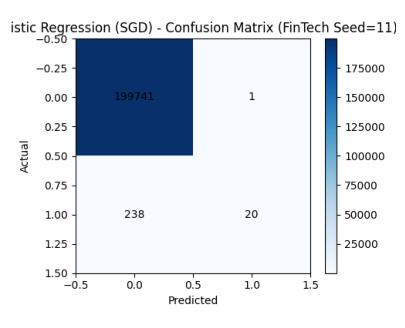

In [ ]:
import json
import matplotlib.pyplot as plt
import os

# Path to LR results
lr_path = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized/seed_11/lr"

print("Showing LR Results (FinTech, Seed = 11)")
print("Directory:", lr_path)

# ==== Load Metrics ====
metrics_file = os.path.join(lr_path, "metrics.json")
with open(metrics_file, "r") as f:
    metrics_lr = json.load(f)

print("\n===== Logistic Regression (SGD) Metrics =====")
for k, v in metrics_lr.items():
    print(f"{k}: {v}")

# ==== Load Classification Report ====
report_file = os.path.join(lr_path, "report.txt")
print("\n===== Classification Report =====\n")
with open(report_file, "r") as f:
    print(f.read())

# ==== Show Confusion Matrix ====
confusion_img = os.path.join(lr_path, "confusion.png")
print("===== Confusion Matrix =====")
img = plt.imread(confusion_img)
plt.figure(figsize=(5, 4))
plt.imshow(img)
plt.axis("off")
plt.show()


In [ ]:
import json
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import os

# Paths
lr_path = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized/seed_11/lr"

metrics_file = os.path.join(lr_path, "metrics.json")
report_file = os.path.join(lr_path, "report.txt")
confusion_img = os.path.join(lr_path, "confusion.png")
pdf_path = os.path.join(lr_path, "model_report.pdf")

# Load metrics
with open(metrics_file, "r") as f:
    metrics_lr = json.load(f)

# Load classification report
with open(report_file, "r") as f:
    report_text = f.read()

# ------- 1. UPDATE report.txt -------
with open(report_file, "w") as f:
    f.write("===== Logistic Regression (SGD) — FinTech Seed 11 Metrics =====\n\n")
    for k, v in metrics_lr.items():
        f.write(f"{k}: {v}\n")
    f.write("\n===== Detailed Classification Report =====\n\n")
    f.write(report_text)

print("Updated report.txt with accuracy included.")


# ------- 2. UPDATE PDF --------
with PdfPages(pdf_path) as pdf:
    fig = plt.figure(figsize=(8.27, 11.69))

    # METRICS BLOCK
    metrics_block = "\n".join([f"{k}: {v}" for k, v in metrics_lr.items()])

    plt.text(
        0.02, 0.98,
        "Logistic Regression (SGD) — FinTech — Seed 11\n\n"
        "===== Model Metrics =====\n"
        f"{metrics_block}\n\n"
        "===== Classification Report =====\n"
        f"{report_text}",
        ha="left", va="top", fontsize=9, family="monospace"
    )
    plt.axis("off")
    pdf.savefig(fig)
    plt.close()

print("Updated PDF with accuracy included.")


Updated report.txt with accuracy included.
Updated PDF with accuracy included.


===== Logistic Regression (SGD) — Metrics (FinTech Seed = 11) =====
model: Logistic Regression (SGD)
seed: 11
accuracy: 0.998805
precision: 0.9523809523809523
recall: 0.07751937984496124
f1: 0.14336917562724014
roc_auc: 0.9237829396821123

===== Updated report.txt =====

===== Logistic Regression (SGD) — FinTech Seed 11 Metrics =====

model: Logistic Regression (SGD)
seed: 11
accuracy: 0.998805
precision: 0.9523809523809523
recall: 0.07751937984496124
f1: 0.14336917562724014
roc_auc: 0.9237829396821123

===== Detailed Classification Report =====

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    199742
           1       0.95      0.08      0.14       258

    accuracy                           1.00    200000
   macro avg       0.98      0.54      0.57    200000
weighted avg       1.00      1.00      1.00    200000

===== Confusion Matrix =====


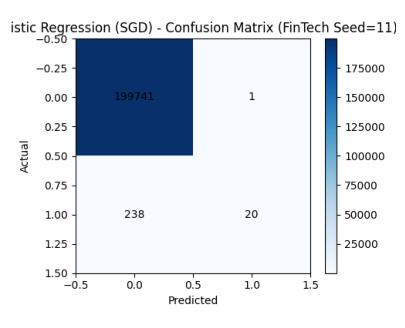

In [ ]:
import json
import matplotlib.pyplot as plt
import os

lr_path = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized/seed_11/lr"

# --- Load metrics.json ---
with open(os.path.join(lr_path, "metrics.json"), "r") as f:
    metrics_lr = json.load(f)

print("===== Logistic Regression (SGD) — Metrics (FinTech Seed = 11) =====")
for k, v in metrics_lr.items():
    print(f"{k}: {v}")

# --- Load updated report.txt ---
print("\n===== Updated report.txt =====\n")
with open(os.path.join(lr_path, "report.txt"), "r") as f:
    print(f.read())

# --- Show confusion matrix image ---
print("===== Confusion Matrix =====")
cm_img_path = os.path.join(lr_path, "confusion.png")
img = plt.imread(cm_img_path)
plt.figure(figsize=(5,4))
plt.imshow(img)
plt.axis("off")
plt.show()


In [ ]:
# ====== Load FULL FinTech dataset for RF & XGB ======

fintech_full_path = "/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech.csv"
df_fintech_full = pd.read_csv(fintech_full_path)

print("Full FinTech Loaded:", df_fintech_full.shape)

# Remove high-cardinality IDs
df_fintech_full = df_fintech_full.drop(columns=["nameOrig", "nameDest"])

target_col = "isFraud"
X_full = df_fintech_full.drop(columns=[target_col])
y_full = df_fintech_full[target_col]

numeric_cols_full = X_full.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_full = X_full.select_dtypes(exclude=[np.number]).columns.tolist()

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

num_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_full = ColumnTransformer(
    transformers=[
        ("num", num_tf, numeric_cols_full),
        ("cat", cat_tf, categorical_cols_full)
    ]
)

from sklearn.model_selection import train_test_split
SEED = 11

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full,
    test_size=0.2, stratify=y_full, random_state=SEED
)

print("RF/XGB Train:", X_train_full.shape, " Test:", X_test_full.shape)


Full FinTech Loaded: (6362620, 11)
RF/XGB Train: (5090096, 8)  Test: (1272524, 8)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import json, os

rf_path = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized/seed_11/rf"
os.makedirs(rf_path, exist_ok=True)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    n_jobs=-1,
    random_state=SEED
)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor_full),
    ("classifier", rf_model)
])

print("Training RF...")
rf_pipeline.fit(X_train_full, y_train_full)

y_pred_rf = rf_pipeline.predict(X_test_full)
y_prob_rf = rf_pipeline.predict_proba(X_test_full)

metrics_rf = {
    "model": "Random Forest",
    "seed": SEED,
    "accuracy": float(accuracy_score(y_test_full, y_pred_rf)),
    "precision": float(precision_score(y_test_full, y_pred_rf, zero_division=0)),
    "recall": float(recall_score(y_test_full, y_pred_rf, zero_division=0)),
    "f1": float(f1_score(y_test_full, y_pred_rf, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test_full, y_prob_rf[:,1]))
}

with open(f"{rf_path}/metrics.json", "w") as f:
    json.dump(metrics_rf, f, indent=4)

joblib.dump(rf_pipeline, f"{rf_path}/model.joblib")

report_rf = classification_report(y_test_full, y_pred_rf, zero_division=0)
with open(f"{rf_path}/report.txt", "w") as f:
    f.write(report_rf)

cm = confusion_matrix(y_test_full, y_pred_rf)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i,j], ha="center")
plt.title("RF Confusion Matrix (FinTech Seed 11)")
plt.savefig(f"{rf_path}/confusion.png")
plt.close()

# PDF
with PdfPages(f"{rf_path}/model_report.pdf") as pdf:
    fig = plt.figure(figsize=(8.27, 11.69))
    plt.text(0.02, 0.98, f"Random Forest - FinTech Seed 11\n\nMetrics:\n{json.dumps(metrics_rf, indent=4)}\n\nReport:\n{report_rf}", fontsize=9, va="top", family="monospace")
    plt.axis("off")
    pdf.savefig(fig)
    plt.close()

print("RF complete.")


Training RF...


KeyboardInterrupt: 

In [ ]:
/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech_sampled_for_experiments.csv


NameError: name 'content' is not defined

In [ ]:
sampled_fintech_path = "/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech_sampled_for_experiments.csv"

df_fintech = pd.read_csv(sampled_fintech_path)

print("Loaded 1M Sampled FinTech Dataset Successfully!")
print("Shape:", df_fintech.shape)
df_fintech.head()


Loaded 1M Sampled FinTech Dataset Successfully!
Shape: (1000000, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,301,CASH_IN,125740.94,C102330765,1057.00,126797.94,C664026329,0.0,0.0,0,0
1,179,PAYMENT,9332.01,C595005133,5203.00,0.00,M2054162886,0.0,0.0,0,0
2,137,CASH_IN,124320.03,C1979232291,40799.00,165119.03,C823257458,1465212.1,1340892.1,0,0
3,285,PAYMENT,15331.24,C1628883018,15190.00,0.00,M1122538824,0.0,0.0,0,0
4,260,PAYMENT,3545.48,C1507810140,31195.79,27650.31,M565272207,0.0,0.0,0,0


In [ ]:
from google.colab import files
files.download("/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech_sampled_for_experiments.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech_sampled_for_experiments.csv


NameError: name 'content' is not defined

In [ ]:
!ls "/content/drive/MyDrive/PhD_FraudDetection/data/fintech"


fintech_balanced_for_FL.csv  fintech_sampled_for_experiments.csv
fintech.csv		     PS_20174392719_1491204439457_log.csv.zip


Loaded FinTech 1M Dataset!
(1000000, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,301,CASH_IN,125740.94,C102330765,1057.00,126797.94,C664026329,0.0,0.0,0,0
1,179,PAYMENT,9332.01,C595005133,5203.00,0.00,M2054162886,0.0,0.0,0,0
2,137,CASH_IN,124320.03,C1979232291,40799.00,165119.03,C823257458,1465212.1,1340892.1,0,0
3,285,PAYMENT,15331.24,C1628883018,15190.00,0.00,M1122538824,0.0,0.0,0,0
4,260,PAYMENT,3545.48,C1507810140,31195.79,27650.31,M565272207,0.0,0.0,0,0


RF Train: (800000, 8)
RF Test: (200000, 8)
Preprocessing for RF completed successfully.


In [ ]:
!ls "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized/seed_runs"


ls: cannot access '/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized/seed_runs': No such file or directory


In [ ]:
!ls "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized/seed_runs"


seed_101  seed_29  seed_555  seed_62  seed_73


In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech_sampled_for_experiments.csv"
df_fintech = pd.read_csv(path)

print(df_fintech.shape)


(1000000, 11)


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

df_fintech = df_fintech.drop(columns=["nameOrig", "nameDest"])
target = "isFraud"

X = df_fintech.drop(columns=[target])
y = df_fintech[target]

numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

num_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_tf, numeric_cols),
    ("cat", cat_tf, categorical_cols)
])


In [ ]:
!ls "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized/seed_runs"


seed_101  seed_29  seed_555  seed_62  seed_73


In [ ]:
!ls "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized"


seed_11  seed_runs


In [ ]:
import os
import json
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# Paths
root_dir = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized"
seed_main = f"{root_dir}/seed_11"
seed_runs = f"{root_dir}/seed_runs"

# All seeds in order
SEEDS = [
    ("seed_11", seed_main),
    ("seed_29", f"{seed_runs}/seed_29"),
    ("seed_62", f"{seed_runs}/seed_62"),
    ("seed_73", f"{seed_runs}/seed_73"),
    ("seed_101", f"{seed_runs}/seed_101"),
    ("seed_555", f"{seed_runs}/seed_555")
]

models = ["lr", "rf", "xgb"]

combined_pdf_path = f"{root_dir}/Centralized_FinTech_All_Seeds_Combined_Report.pdf"

print("Generating Master Combined PDF...\n")

with PdfPages(combined_pdf_path) as pdf:

    for seed_label, seed_path in SEEDS:
        print(f"Adding results for {seed_label}...")

        for model in models:
            model_dir = f"{seed_path}/{model}"

            metrics_path = f"{model_dir}/metrics.json"
            report_path = f"{model_dir}/report.txt"
            confusion_path = f"{model_dir}/confusion.png"

            # Load data
            with open(metrics_path, "r") as f:
                metrics = json.load(f)
            with open(report_path, "r") as f:
                clf_report = f.read()

            # ========== PAGE 1: METRICS + REPORT ==========
            fig = plt.figure(figsize=(8.27, 11.69))  # A4
            text_block = (
                f"{model.upper()} — Centralized FinTech ({seed_label})\n\n"
                f"===== METRICS =====\n"
                f"Accuracy:   {metrics['accuracy']}\n"
                f"Precision:  {metrics['precision']}\n"
                f"Recall:     {metrics['recall']}\n"
                f"F1-score:   {metrics['f1']}\n"
                f"ROC-AUC:    {metrics['roc_auc']}\n\n"
                f"===== CLASSIFICATION REPORT =====\n\n"
                f"{clf_report}"
            )

            plt.text(0.02, 0.98, text_block, va='top', fontsize=9, family='monospace')
            plt.axis("off")
            pdf.savefig(fig)
            plt.close()

            # ========== PAGE 2: CONFUSION MATRIX ==========
            fig = plt.figure(figsize=(8.27, 11.69))
            cm_img = plt.imread(confusion_path)
            plt.imshow(cm_img)
            plt.axis("off")
            plt.title(f"{model.upper()} Confusion Matrix ({seed_label})")
            pdf.savefig(fig)
            plt.close()

print("\n🎉 Master PDF Generated Successfully!")
print("Saved at:")
print(combined_pdf_path)


Generating Master Combined PDF...

Adding results for seed_11...
Adding results for seed_29...
Adding results for seed_62...
Adding results for seed_73...
Adding results for seed_101...
Adding results for seed_555...

🎉 Master PDF Generated Successfully!
Saved at:
/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized/Centralized_FinTech_All_Seeds_Combined_Report.pdf


In [ ]:
!ls "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized/seed_11"


Centralized_FinTech_Seed11_Combined_Report.pdf	lr  rf	xgb


In [ ]:
!ls "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized/seed_runs/seed_29"


lr  rf	xgb


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Load FinTech 1M dataset
df_fintech = pd.read_csv("/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech_sampled_for_experiments.csv")

# Prepare dataset
df_fintech = df_fintech.drop(columns=["nameOrig", "nameDest"])
target = "isFraud"
X = df_fintech.drop(columns=[target])
y = df_fintech[target]

numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

num_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_tf = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_tf, numeric_cols),
    ("cat", cat_tf, categorical_cols)
])

print("FinTech dataset + preprocessing ready for random runs.")


FinTech dataset + preprocessing ready for random runs.


In [ ]:
import os
import json
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Output directory
base_out = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized/random_runs"
os.makedirs(base_out, exist_ok=True)

RUNS = [1, 2, 3, 4, 5]
models = {
    "lr": SGDClassifier(loss="log_loss"),
    "rf": RandomForestClassifier(n_estimators=300, n_jobs=-1),
    "xgb": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        n_jobs=-1,
        eval_metric="logloss"
    )
}

for run_id in RUNS:

    print(f"\n======================")
    print(f"Starting RANDOM RUN {run_id}")
    print("======================\n")

    # Create folder for this run
    run_dir = f"{base_out}/run_{run_id}"
    os.makedirs(run_dir, exist_ok=True)

    # Split with random seed
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=None  # RANDOM
    )

    for model_name, model in models.items():

        print(f"Training {model_name.upper()} for run {run_id}...")

        model_out = f"{run_dir}/{model_name}"
        os.makedirs(model_out, exist_ok=True)

        pipe = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]

        # Metrics
        metrics = {
            "model": model_name.upper(),
            "run": run_id,
            "accuracy": float(accuracy_score(y_test, y_pred)),
            "precision": float(precision_score(y_test, y_pred, zero_division=0)),
            "recall": float(recall_score(y_test, y_pred, zero_division=0)),
            "f1": float(f1_score(y_test, y_pred, zero_division=0)),
            "roc_auc": float(roc_auc_score(y_test, y_prob))
        }

        with open(f"{model_out}/metrics.json", "w") as f:
            json.dump(metrics, f, indent=4)

        # Classification report
        report = classification_report(y_test, y_pred, zero_division=0)
        with open(f"{model_out}/report.txt", "w") as f:
            f.write(report)

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(5, 4))
        plt.imshow(cm, cmap="Blues")
        plt.title(f"{model_name.upper()} Confusion Matrix (Run={run_id})")
        plt.colorbar()
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, cm[i, j], ha='center', va='center')
        plt.tight_layout()
        plt.savefig(f"{model_out}/confusion.png")
        plt.close()

        print(f"✔ Completed {model_name.upper()} for Random Run {run_id}")

print("\n🎉 ALL RANDOM RUNS COMPLETED!")



Starting RANDOM RUN 1

Training LR for run 1...
✔ Completed LR for Random Run 1
Training RF for run 1...
✔ Completed RF for Random Run 1
Training XGB for run 1...
✔ Completed XGB for Random Run 1

Starting RANDOM RUN 2

Training LR for run 2...
✔ Completed LR for Random Run 2
Training RF for run 2...
✔ Completed RF for Random Run 2
Training XGB for run 2...
✔ Completed XGB for Random Run 2

Starting RANDOM RUN 3

Training LR for run 3...
✔ Completed LR for Random Run 3
Training RF for run 3...
✔ Completed RF for Random Run 3
Training XGB for run 3...
✔ Completed XGB for Random Run 3

Starting RANDOM RUN 4

Training LR for run 4...
✔ Completed LR for Random Run 4
Training RF for run 4...
✔ Completed RF for Random Run 4
Training XGB for run 4...
✔ Completed XGB for Random Run 4

Starting RANDOM RUN 5

Training LR for run 5...
✔ Completed LR for Random Run 5
Training RF for run 5...
✔ Completed RF for Random Run 5
Training XGB for run 5...
✔ Completed XGB for Random Run 5

🎉 ALL RANDOM R

In [ ]:
import os
import json
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

root_dir = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized/random_runs"
RUNS = [1, 2, 3, 4, 5]
models = ["lr", "rf", "xgb"]

combined_pdf_path = f"{root_dir}/FinTech_RandomRuns_Combined_Report.pdf"

print("Generating Combined PDF for Random Runs...\n")

with PdfPages(combined_pdf_path) as pdf:

    for run_id in RUNS:

        run_path = f"{root_dir}/run_{run_id}"
        print(f"Adding results for RUN {run_id}...")

        for model in models:

            model_dir = f"{run_path}/{model}"

            metrics_path = f"{model_dir}/metrics.json"
            report_path = f"{model_dir}/report.txt"
            confusion_path = f"{model_dir}/confusion.png"

            # Load data
            with open(metrics_path, "r") as f:
                metrics = json.load(f)
            with open(report_path, "r") as f:
                clf_report = f.read()

            # ========== PAGE 1: METRICS + REPORT ==========
            fig = plt.figure(figsize=(8.27, 11.69))  # A4
            text_block = (
                f"{model.upper()} — FinTech RANDOM RUN {run_id}\n\n"
                f"===== METRICS =====\n"
                f"Accuracy:   {metrics['accuracy']}\n"
                f"Precision:  {metrics['precision']}\n"
                f"Recall:     {metrics['recall']}\n"
                f"F1-score:   {metrics['f1']}\n"
                f"ROC-AUC:    {metrics['roc_auc']}\n\n"
                f"===== CLASSIFICATION REPORT =====\n\n"
                f"{clf_report}"
            )

            plt.text(0.02, 0.98, text_block, va='top', fontsize=9, family='monospace')
            plt.axis("off")
            pdf.savefig(fig)
            plt.close()

            # ========== PAGE 2: CONFUSION MATRIX ==========
            fig = plt.figure(figsize=(8.27, 11.69))
            cm_img = plt.imread(confusion_path)
            plt.imshow(cm_img)
            plt.axis("off")
            plt.title(f"{model.upper()} Confusion Matrix – Run {run_id}")
            pdf.savefig(fig)
            plt.close()

print("\n🎉 PDF Created Successfully!")
print("Saved at:", combined_pdf_path)


Generating Combined PDF for Random Runs...

Adding results for RUN 1...
Adding results for RUN 2...
Adding results for RUN 3...
Adding results for RUN 4...
Adding results for RUN 5...

🎉 PDF Created Successfully!
Saved at: /content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized/random_runs/FinTech_RandomRuns_Combined_Report.pdf


In [ ]:
import os
import json
import pandas as pd

root_dir = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/centralized/random_runs"
RUNS = [1, 2, 3, 4, 5]
models = ["lr", "rf", "xgb"]

rows = []

for run_id in RUNS:
    for model in models:
        metrics_path = f"{root_dir}/run_{run_id}/{model}/metrics.json"
        with open(metrics_path, "r") as f:
            metrics = json.load(f)
            rows.append(metrics)

df_random = pd.DataFrame(rows)
df_random


,model,run,accuracy,precision,recall,f1,roc_auc
0,LR,1,0.998810,0.916667,0.085271,0.156028,0.907774
1,RF,1,0.999615,0.978836,0.717054,0.827740,0.993730
2,XGB,1,0.999650,0.947619,0.771318,0.850427,0.998973
3,LR,2,0.998800,0.909091,0.077519,0.142857,0.927328
4,RF,2,0.999615,0.983957,0.713178,0.826966,0.995472
5,XGB,2,0.999660,0.952381,0.775194,0.854701,0.999586
6,LR,3,0.998825,0.960000,0.093023,0.169611,0.926603
7,RF,3,0.999600,0.958763,0.720930,0.823009,0.993703
8,XGB,3,0.999695,0.958140,0.798450,0.871036,0.997983
9,LR,4,0.998815,0.956522,0.085271,0.156584,0.915325


In [ ]:
# ---------- Federated FinTech (seed=11) simulation ----------
import os, json, joblib, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# ---------- Settings ----------
SEED = 11
n_clients = 10
n_rounds = 5
sampled_path = "/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech_sampled_for_experiments.csv"
output_root = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_11"
os.makedirs(output_root, exist_ok=True)

# ---------- Load dataset ----------
df = pd.read_csv(sampled_path)
df = df.drop(columns=["nameOrig", "nameDest"])
target = "isFraud"

# Single global train/test split (keeps same evaluation set as centralized)
X_all = df.drop(columns=[target])
y_all = df[target]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=SEED
)

print("Global train:", X_train_full.shape, "Global test:", X_test.shape)

# ---------- Preprocessor: fit once on the global training set and reuse ----------
numeric_cols = X_train_full.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train_full.select_dtypes(exclude=["number"]).columns.tolist()

num_tf = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
cat_tf = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocessor = ColumnTransformer([("num", num_tf, numeric_cols), ("cat", cat_tf, categorical_cols)], remainder="drop")
preprocessor.fit(X_train_full)   # fit once

# Pre-transform test set once
X_test_pre = preprocessor.transform(X_test)

# ---------- Partition training set into clients (stratified by label) ----------
# We'll create indices per client to preserve fraud ratio in each client
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=n_clients, shuffle=True, random_state=SEED)
client_indices = []
y_train_full_array = y_train_full.values
X_train_full_indexed = X_train_full.reset_index(drop=True)
for _, test_idx in skf.split(X_train_full_indexed, y_train_full_array):
    client_indices.append(test_idx)

client_sizes = [len(idx) for idx in client_indices]
print("Client sizes:", client_sizes, "Total:", sum(client_sizes), "Expected:", len(X_train_full))

# ---------- Helper: evaluate and save results ----------
def save_metrics_and_report(model_label, out_dir, y_true, y_pred, y_prob):
    metrics = {
        "model": model_label,
        "seed": SEED,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob))
    }
    with open(f"{out_dir}/metrics.json", "w") as f:
        json.dump(metrics, f, indent=4)
    # report
    rep = classification_report(y_true, y_pred, zero_division=0)
    with open(f"{out_dir}/report.txt", "w") as f:
        f.write(rep)
    # confusion
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{model_label} - Confusion Matrix (Federated Seed={SEED})")
    plt.colorbar()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center')
    plt.tight_layout()
    plt.savefig(f"{out_dir}/confusion.png")
    plt.close()
    # PDF single page summary + confusion page
    pdf_path = f"{out_dir}/model_report.pdf"
    with PdfPages(pdf_path) as pdf:
        # page 1 metrics + report
        fig = plt.figure(figsize=(8.27, 11.69))
        text_block = f"{model_label} — Federated FinTech (Seed={SEED})\n\nMetrics:\n{json.dumps(metrics, indent=4)}\n\nClassification report:\n{rep}"
        plt.text(0.01, 0.99, text_block, ha="left", va="top", fontsize=9, family="monospace")
        plt.axis("off")
        pdf.savefig(fig); plt.close()
        # page 2 confusion
        fig = plt.figure(figsize=(8.27, 11.69))
        img = plt.imread(f"{out_dir}/confusion.png")
        plt.imshow(img); plt.axis("off")
        pdf.savefig(fig); plt.close()
    return metrics

# ---------- Federated Logistic Regression via FedAvg on parameters ----------
lr_out = os.path.join(output_root, "lr"); os.makedirs(lr_out, exist_ok=True)
print("\n=== Federated Logistic Regression (SGD + FedAvg) ===")

# Initialize global parameters with a cold SGDClassifier (we will set coef_ after first round)
global_lr = SGDClassifier(loss="log_loss", max_iter=1000, tol=1e-3, random_state=SEED)
# We need to initialize global model by calling partial_fit on a small batch (use classes)
classes = np.unique(y_train_full_array)
# create a dummy init by fitting on a tiny subset to get coef_ shape
small_X = preprocessor.transform(X_train_full.iloc[:10])
small_y = y_train_full_array[:10]
global_lr.partial_fit(small_X, small_y, classes=classes)

# Federated rounds
for rnd in range(1, n_rounds + 1):
    client_coefs = []
    client_intercepts = []
    client_weights = []
    print(f"\n-- LR Federated Round {rnd}/{n_rounds} --")
    # each client trains locally (starting from global params) via partial_fit on client's data
    for c_idx, idxs in enumerate(client_indices):
        Xc = X_train_full_indexed.loc[idxs]
        yc = y_train_full_array[idxs]
        Xc_pre = preprocessor.transform(Xc)
        # local model: start from global params by creating new clf and setting coef_
        local = SGDClassifier(loss="log_loss", max_iter=1000, tol=1e-3, random_state=SEED)
        # initialize local coef using global
        local.partial_fit(small_X, small_y, classes=classes)  # init shapes
        # overwrite weights with global's current params
        local.coef_ = global_lr.coef_.copy()
        local.intercept_ = global_lr.intercept_.copy()
        # perform local update via partial_fit (single pass)
        local.partial_fit(Xc_pre, yc, classes=classes)
        client_coefs.append(local.coef_ * len(idxs))
        client_intercepts.append(local.intercept_ * len(idxs))
        client_weights.append(len(idxs))
    # FedAvg: weighted average of parameters
    total = sum(client_weights)
    avg_coef = sum(client_coefs) / total
    avg_intercept = sum(client_intercepts) / total
    # update global model
    global_lr.coef_ = avg_coef
    global_lr.intercept_ = avg_intercept
    print(f"FedAvg applied. Global params updated after round {rnd}.")

# Evaluate global_lr on global test set
y_pred_lr = global_lr.predict(X_test_pre)
y_prob_lr = global_lr.predict_proba(X_test_pre)[:, 1]

metrics_lr = save_metrics_and_report("LR_Federated", lr_out, y_test, y_pred_lr, y_prob_lr)
joblib.dump(global_lr, f"{lr_out}/global_model.joblib")
print("Federated LR finished. Metrics:", metrics_lr)

# ---------- Federated RF & XGB via local models + ensemble averaging ----------
def train_clients_ensemble(ModelClass, model_kwargs, model_name):
    out_dir = os.path.join(output_root, model_name.lower()); os.makedirs(out_dir, exist_ok=True)
    print(f"\n=== Federated {model_name}: train clients for {n_rounds} rounds (ensemble aggregation) ===")
    # We'll collect final client models from last round (or keep models from last round)
    client_models = [None] * n_clients
    for rnd in range(1, n_rounds + 1):
        print(f"-- {model_name} Round {rnd}/{n_rounds} --")
        for c_idx, idxs in enumerate(client_indices):
            Xc = X_train_full_indexed.loc[idxs]
            yc = y_train_full_array[idxs]
            Xc_pre = preprocessor.transform(Xc)
            # instantiate and train local model
            local = ModelClass(**model_kwargs)
            local.fit(Xc_pre, yc)
            client_models[c_idx] = local
        # optional: could evaluate intermediate global ensemble here
    # After rounds, evaluate by averaging predicted probabilities across client_models
    # Weighted average by client size
    weights = np.array([len(idxs) for idxs in client_indices], dtype=float)
    weights = weights / weights.sum()
    # compute averaged probability on test set
    prob_sum = np.zeros((X_test_pre.shape[0],))
    for c_idx, model in enumerate(client_models):
        probs = model.predict_proba(X_test_pre)[:, 1]
        prob_sum += probs * weights[c_idx]
    y_prob_global = prob_sum
    y_pred_global = (y_prob_global >= 0.5).astype(int)
    # Save ensemble models list
    joblib.dump(client_models, f"{out_dir}/client_models_round{n_rounds}.joblib")
    # Save metrics and report
    metrics = save_metrics_and_report(f"{model_name}_FederatedEnsemble", out_dir, y_test, y_pred_global, y_prob_global)
    return metrics

# RF federated
rf_metrics = train_clients_ensemble(RandomForestClassifier, {"n_estimators":150, "n_jobs":-1, "random_state":SEED}, "RF")
print("Federated RF finished. Metrics:", rf_metrics)

# XGB federated
xgb_metrics = train_clients_ensemble(XGBClassifier,
                                    {"n_estimators":150, "max_depth":5, "learning_rate":0.1,
                                     "subsample":0.8, "colsample_bytree":0.8, "random_state":SEED, "use_label_encoder":False, "eval_metric":"logloss", "n_jobs":-1},
                                    "XGB")
print("Federated XGB finished. Metrics:", xgb_metrics)

# ---------- Combined PDF for federated results (LR, RF, XGB) ----------
combined_pdf = os.path.join(output_root, "Federated_FinTech_Seed11_Combined_Report.pdf")
with PdfPages(combined_pdf) as pdf:
    for model_name in ["lr", "rf", "xgb"]:
        mdir = os.path.join(output_root, model_name)
        metrics_path = os.path.join(mdir, "metrics.json")
        report_path = os.path.join(mdir, "report.txt")
        conf_path = os.path.join(mdir, "confusion.png")
        with open(metrics_path, "r") as f:
            metrics = json.load(f)
        with open(report_path, "r") as f:
            report_txt = f.read()
        # Page 1: metrics + report
        fig = plt.figure(figsize=(8.27,11.69))
        txt = f"{model_name.upper()} — Federated FinTech (Seed={SEED})\n\nMetrics:\n{json.dumps(metrics, indent=4)}\n\nReport:\n{report_txt}"
        plt.text(0.01,0.99,txt,va="top",fontsize=9,family="monospace")
        plt.axis("off")
        pdf.savefig(fig); plt.close()
        # Page 2: confusion
        fig = plt.figure(figsize=(8.27,11.69))
        img = plt.imread(conf_path)
        plt.imshow(img); plt.axis("off")
        pdf.savefig(fig); plt.close()

print("\n=== Federated simulation complete. Combined PDF saved at: ===")
print(combined_pdf)


Global train: (800000, 8) Global test: (200000, 8)
Client sizes: [80000, 80000, 80000, 80000, 80000, 80000, 80000, 80000, 80000, 80000] Total: 800000 Expected: 800000

=== Federated Logistic Regression (SGD + FedAvg) ===

-- LR Federated Round 1/5 --
FedAvg applied. Global params updated after round 1.

-- LR Federated Round 2/5 --
FedAvg applied. Global params updated after round 2.

-- LR Federated Round 3/5 --
FedAvg applied. Global params updated after round 3.

-- LR Federated Round 4/5 --
FedAvg applied. Global params updated after round 4.

-- LR Federated Round 5/5 --
FedAvg applied. Global params updated after round 5.
Federated LR finished. Metrics: {'model': 'LR_Federated', 'seed': 11, 'accuracy': 0.99879, 'precision': 0.9444444444444444, 'recall': 0.06589147286821706, 'f1': 0.12318840579710146, 'roc_auc': 0.8975167889057506}

=== Federated RF: train clients for 5 rounds (ensemble aggregation) ===
-- RF Round 1/5 --
-- RF Round 2/5 --
-- RF Round 3/5 --
-- RF Round 4/5 --
--

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:05] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:06] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:07] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:07] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:08] WARNING: /w

-- XGB Round 2/5 --


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:15] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:16] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:17] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:18] WARNING: /w

-- XGB Round 3/5 --


...

-- XGB Round 4/5 --


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:32] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:33] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:34] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:35] WARNING: /w

-- XGB Round 5/5 --


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:42] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:43] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:43] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:44] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:26:45] WARNING: /w

Federated XGB finished. Metrics: {'model': 'XGB_FederatedEnsemble', 'seed': 11, 'accuracy': 0.999595, 'precision': 1.0, 'recall': 0.686046511627907, 'f1': 0.8137931034482758, 'roc_auc': 0.995966812692249}

=== Federated simulation complete. Combined PDF saved at: ===
/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_11/Federated_FinTech_Seed11_Combined_Report.pdf


In [ ]:
# ---------- Federated FinTech: run for seeds [29,62,73,101,555] (Option A) ----------
import os, json, joblib, math, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# ---------- Settings ----------
SEEDS_TO_RUN = [29, 62, 73, 101, 555]
n_clients = 10
n_rounds = 5
sampled_path = "/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech_sampled_for_experiments.csv"
root_output = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated"
os.makedirs(root_output, exist_ok=True)

# ---------- Helper functions ----------
def save_metrics_and_report(model_label, out_dir, y_true, y_pred, y_prob):
    metrics = {
        "model": model_label,
        "seed": seed,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob))
    }
    with open(f"{out_dir}/metrics.json", "w") as f:
        json.dump(metrics, f, indent=4)
    # report
    rep = classification_report(y_true, y_pred, zero_division=0)
    with open(f"{out_dir}/report.txt", "w") as f:
        f.write(rep)
    # confusion
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{model_label} - Confusion Matrix (Federated Seed={seed})")
    plt.colorbar()
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center')
    plt.tight_layout()
    plt.savefig(f"{out_dir}/confusion.png")
    plt.close()
    # PDF single page summary + confusion page
    pdf_path = f"{out_dir}/model_report.pdf"
    with PdfPages(pdf_path) as pdf:
        # page 1 metrics + report
        fig = plt.figure(figsize=(8.27, 11.69))
        text_block = f"{model_label} — Federated FinTech (Seed={seed})\n\nMetrics:\n{json.dumps(metrics, indent=4)}\n\nClassification report:\n{rep}"
        plt.text(0.01, 0.99, text_block, ha="left", va="top", fontsize=9, family="monospace")
        plt.axis("off")
        pdf.savefig(fig); plt.close()
        # page 2 confusion
        fig = plt.figure(figsize=(8.27, 11.69))
        img = plt.imread(f"{out_dir}/confusion.png")
        plt.imshow(img); plt.axis("off")
        pdf.savefig(fig); plt.close()
    return metrics

# ---------- Load sampled dataset once (we will re-split per seed) ----------
df_all = pd.read_csv(sampled_path)
print("Sampled FinTech loaded:", df_all.shape)

target_col = "isFraud"

# ---------- Loop over seeds ----------
master_seed_reports = []
start_all = time.time()

for seed in SEEDS_TO_RUN:
    t0 = time.time()
    print("\n" + "="*60)
    print(f"Starting Federated simulation for SEED = {seed}")
    print("="*60 + "\n")

    # Create seed-specific output root
    seed_out_root = os.path.join(root_output, f"seed_{seed}")
    os.makedirs(seed_out_root, exist_ok=True)

    # Global train/test split (consistent eval set for this seed)
    df = df_all.copy()
    df = df.drop(columns=["nameOrig", "nameDest"])
    X_all = df.drop(columns=[target_col])
    y_all = df[target_col]

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_all, y_all, test_size=0.2, stratify=y_all, random_state=seed
    )

    print("Global train:", X_train_full.shape, "Global test:", X_test.shape)

    # Fit preprocessor once on train and transform test
    numeric_cols = X_train_full.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = X_train_full.select_dtypes(exclude=["number"]).columns.tolist()

    num_tf = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])
    cat_tf = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

    preprocessor = ColumnTransformer([("num", num_tf, numeric_cols), ("cat", cat_tf, categorical_cols)], remainder="drop")
    preprocessor.fit(X_train_full)

    X_test_pre = preprocessor.transform(X_test)

    # Partition train into n_clients stratified
    X_train_full_indexed = X_train_full.reset_index(drop=True)
    y_train_full_array = y_train_full.reset_index(drop=True).values

    skf = StratifiedKFold(n_splits=n_clients, shuffle=True, random_state=seed)
    client_indices = []
    for _, idx in skf.split(X_train_full_indexed, y_train_full_array):
        client_indices.append(idx.tolist())
    client_sizes = [len(idx) for idx in client_indices]
    print("Client sizes:", client_sizes, "Total:", sum(client_sizes))

    # ---------- Federated LR (FedAvg on coefficients) ----------
    lr_out = os.path.join(seed_out_root, "lr"); os.makedirs(lr_out, exist_ok=True)
    print("\n--- Federated Logistic Regression (FedAvg) ---")
    # initialize global SGDClassifier to get shapes
    global_lr = SGDClassifier(loss="log_loss", max_iter=1000, tol=1e-3, random_state=seed)
    # small init to set coef_ shape
    small_X = preprocessor.transform(X_train_full.iloc[:10])
    small_y = y_train_full_array[:10]
    classes = np.unique(y_train_full_array)
    global_lr.partial_fit(small_X, small_y, classes=classes)

    for rnd in range(1, n_rounds + 1):
        client_coefs = []
        client_intercepts = []
        client_weights = []
        print(f"LR Round {rnd}/{n_rounds}")
        for c_idx, idxs in enumerate(client_indices):
            Xc = X_train_full_indexed.loc[idxs]
            yc = y_train_full_array[idxs]
            Xc_pre = preprocessor.transform(Xc)
            # local model: initialize and load global params
            local = SGDClassifier(loss="log_loss", max_iter=1000, tol=1e-3, random_state=seed)
            local.partial_fit(small_X, small_y, classes=classes)  # init shapes
            # copy global params
            local.coef_ = global_lr.coef_.copy()
            local.intercept_ = global_lr.intercept_.copy()
            # local update
            local.partial_fit(Xc_pre, yc, classes=classes)
            client_coefs.append(local.coef_ * len(idxs))
            client_intercepts.append(local.intercept_ * len(idxs))
            client_weights.append(len(idxs))
        # FedAvg
        total = sum(client_weights)
        avg_coef = sum(client_coefs) / total
        avg_intercept = sum(client_intercepts) / total
        global_lr.coef_ = avg_coef
        global_lr.intercept_ = avg_intercept
        print(f" FedAvg applied for round {rnd}")

    # Evaluate global LR
    y_pred_lr = global_lr.predict(X_test_pre)
    y_prob_lr = global_lr.predict_proba(X_test_pre)[:, 1]
    metrics_lr = save_metrics_and_report("LR_Federated", lr_out, y_test.values, y_pred_lr, y_prob_lr)
    joblib.dump(global_lr, os.path.join(lr_out, "global_model.joblib"))
    print(" LR saved. Metrics:", metrics_lr)

    # ---------- Federated RF & XGB via client ensembles ----------
    def train_clients_ensemble(ModelClass, model_kwargs, model_name):
        out_dir = os.path.join(seed_out_root, model_name.lower()); os.makedirs(out_dir, exist_ok=True)
        print(f"\n--- Federated {model_name} (ensemble aggregation) ---")
        client_models = [None] * n_clients
        for rnd in range(1, n_rounds + 1):
            print(f"{model_name} Round {rnd}/{n_rounds}")
            for c_idx, idxs in enumerate(client_indices):
                Xc = X_train_full_indexed.loc[idxs]
                yc = y_train_full_array[idxs]
                Xc_pre = preprocessor.transform(Xc)
                local = ModelClass(**model_kwargs)
                local.fit(Xc_pre, yc)
                client_models[c_idx] = local
        # Weighted average of probabilities on test set
        weights = np.array([len(idxs) for idxs in client_indices], dtype=float)
        weights = weights / weights.sum()
        prob_sum = np.zeros(X_test_pre.shape[0], dtype=float)
        for c_idx, model in enumerate(client_models):
            probs = model.predict_proba(X_test_pre)[:, 1]
            prob_sum += probs * weights[c_idx]
        y_prob_global = prob_sum
        y_pred_global = (y_prob_global >= 0.5).astype(int)
        # Save client models
        joblib.dump(client_models, os.path.join(out_dir, f"client_models_round{n_rounds}.joblib"))
        # Save metrics & files
        metrics = save_metrics_and_report(f"{model_name}_FederatedEnsemble", out_dir, y_test.values, y_pred_global, y_prob_global)
        return metrics

    # RF
    rf_metrics = train_clients_ensemble(RandomForestClassifier, {"n_estimators":150, "n_jobs":-1, "random_state":seed}, "RF")
    print(" RF done. Metrics:", rf_metrics)

    # XGB
    xgb_metrics = train_clients_ensemble(XGBClassifier,
                                        {"n_estimators":150, "max_depth":5, "learning_rate":0.1,
                                         "subsample":0.8, "colsample_bytree":0.8, "random_state":seed, "use_label_encoder":False, "eval_metric":"logloss", "n_jobs":-1},
                                        "XGB")
    print(" XGB done. Metrics:", xgb_metrics)

    # ---------- Per-seed combined PDF ----------
    combined_pdf = os.path.join(seed_out_root, f"Federated_FinTech_Seed{seed}_Combined_Report.pdf")
    with PdfPages(combined_pdf) as pdf:
        for model_name in ["lr", "rf", "xgb"]:
            mdir = os.path.join(seed_out_root, model_name)
            metrics_path = os.path.join(mdir, "metrics.json")
            report_path = os.path.join(mdir, "report.txt")
            conf_path = os.path.join(mdir, "confusion.png")
            with open(metrics_path, "r") as f:
                metrics = json.load(f)
            with open(report_path, "r") as f:
                report_txt = f.read()
            # Page 1 metrics+report
            fig = plt.figure(figsize=(8.27,11.69))
            txt = f"{model_name.upper()} — Federated FinTech (Seed={seed})\n\nMetrics:\n{json.dumps(metrics, indent=4)}\n\nReport:\n{report_txt}"
            plt.text(0.01,0.99,txt,va="top",fontsize=9,family="monospace")
            plt.axis("off"); pdf.savefig(fig); plt.close()
            # Page 2 confusion
            fig = plt.figure(figsize=(8.27,11.69))
            img = plt.imread(conf_path)
            plt.imshow(img); plt.axis("off"); pdf.savefig(fig); plt.close()
    print(f"Combined PDF for seed {seed} saved at: {combined_pdf}")

    # store brief seed metrics for later master PDF
    master_seed_reports.append({
        "seed": seed,
        "lr": lr_out,
        "rf": os.path.join(seed_out_root, "rf"),
        "xgb": os.path.join(seed_out_root, "xgb")
    })

    t1 = time.time()
    print(f"Seed {seed} finished in {round(t1-t0,1)} sec")

# ---------- Master PDF combining all seeds ----------
master_pdf = os.path.join(root_output, "Federated_FinTech_All_Seeds_Combined_Report.pdf")
with PdfPages(master_pdf) as pdf:
    # iterate in order: include seed11 first (already exists) then seeds we ran
    ordered_seeds = [("seed_11", os.path.join(root_output, "seed_11"))] + [(f"seed_{s}", os.path.join(root_output, f"seed_{s}")) for s in SEEDS_TO_RUN]
    for seed_label, seed_path in ordered_seeds:
        if not os.path.exists(seed_path):
            print("Warning: seed path not found:", seed_path)
            continue
        for model in ["lr","rf","xgb"]:
            mdir = os.path.join(seed_path, model)
            metrics_path = os.path.join(mdir, "metrics.json")
            report_path = os.path.join(mdir, "report.txt")
            confusion_path = os.path.join(mdir, "confusion.png")
            if not (os.path.exists(metrics_path) and os.path.exists(report_path) and os.path.exists(confusion_path)):
                print("Missing files for", seed_label, model)
                continue
            with open(metrics_path, "r") as f:
                metrics = json.load(f)
            with open(report_path, "r") as f:
                report_txt = f.read()
            # metrics/report page
            fig = plt.figure(figsize=(8.27,11.69))
            txt = f"{model.upper()} — Federated FinTech ({seed_label})\n\nMetrics:\n{json.dumps(metrics, indent=4)}\n\nReport:\n{report_txt}"
            plt.text(0.01,0.99,txt,va="top",fontsize=9,family="monospace")
            plt.axis("off"); pdf.savefig(fig); plt.close()
            # confusion page
            fig = plt.figure(figsize=(8.27,11.69))
            img = plt.imread(confusion_path)
            plt.imshow(img); plt.axis("off"); pdf.savefig(fig); plt.close()

print("\n=== ALL SEEDS FEDERATED COMPLETED ===")
print("Master combined federated PDF saved at:", master_pdf)
print("Per-seed combined PDFs saved under:", root_output)
print("Total time (s):", round(time.time() - start_all, 1))


Sampled FinTech loaded: (1000000, 11)

Starting Federated simulation for SEED = 29

Global train: (800000, 8) Global test: (200000, 8)
Client sizes: [80000, 80000, 80000, 80000, 80000, 80000, 80000, 80000, 80000, 80000] Total: 800000

--- Federated Logistic Regression (FedAvg) ---
LR Round 1/5
 FedAvg applied for round 1
LR Round 2/5
 FedAvg applied for round 2
LR Round 3/5
 FedAvg applied for round 3
LR Round 4/5
 FedAvg applied for round 4
LR Round 5/5
 FedAvg applied for round 5
 LR saved. Metrics: {'model': 'LR_Federated', 'seed': 29, 'accuracy': 0.998795, 'precision': 1.0, 'recall': 0.06589147286821706, 'f1': 0.12363636363636364, 'roc_auc': 0.8813854562307858}

--- Federated RF (ensemble aggregation) ---
RF Round 1/5
RF Round 2/5
RF Round 3/5
RF Round 4/5
RF Round 5/5
 RF done. Metrics: {'model': 'RF_FederatedEnsemble', 'seed': 29, 'accuracy': 0.99959, 'precision': 0.9943820224719101, 'recall': 0.686046511627907, 'f1': 0.8119266055045872, 'roc_auc': 0.9990811499547595}

--- Federa

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:03] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:04] WARNING: /w

XGB Round 2/5


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:09] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:10] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:11] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:14] WARNING: /w

XGB Round 3/5


...

XGB Round 4/5


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:31] WARNING: /w

XGB Round 5/5


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:36] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:37] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:38] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:40] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [14:45:41] WARNING: /w

 XGB done. Metrics: {'model': 'XGB_FederatedEnsemble', 'seed': 29, 'accuracy': 0.99957, 'precision': 1.0, 'recall': 0.6666666666666666, 'f1': 0.8, 'roc_auc': 0.9994531899638907}
Combined PDF for seed 29 saved at: /content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_29/Federated_FinTech_Seed29_Combined_Report.pdf
Seed 29 finished in 517.2 sec

Starting Federated simulation for SEED = 62

Global train: (800000, 8) Global test: (200000, 8)
Client sizes: [80000, 80000, 80000, 80000, 80000, 80000, 80000, 80000, 80000, 80000] Total: 800000

--- Federated Logistic Regression (FedAvg) ---
LR Round 1/5
 FedAvg applied for round 1
LR Round 2/5
 FedAvg applied for round 2
LR Round 3/5
 FedAvg applied for round 3
LR Round 4/5
 FedAvg applied for round 4
LR Round 5/5
 FedAvg applied for round 5
 LR saved. Metrics: {'model': 'LR_Federated', 'seed': 62, 'accuracy': 0.99881, 'precision': 0.9545454545454546, 'recall': 0.08139534883720931, 'f1': 0.15, 'roc_auc': 0.8546636013170168}



In [ ]:
import os

BASE = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated"

expected_seeds = [11, 29, 62, 73, 101, 555]

print("Checking Federated FinTech Results...\n")

# Check if base folder exists
if not os.path.exists(BASE):
    print("❌ Federated FinTech folder not found in Drive.")
else:
    print(f"📁 Found folder: {BASE}\n")

# Check individual seed folders
for seed in expected_seeds:
    seed_path = f"{BASE}/seed_{seed}"
    print(f"--- Seed {seed} ---")

    if os.path.exists(seed_path):
        print(f"✔ Folder exists: seed_{seed}")

        # List PDFs inside seed folder
        pdfs = [f for f in os.listdir(seed_path) if f.endswith(".pdf")]
        if pdfs:
            print("   PDFs found:")
            for p in pdfs:
                print("   •", p)
        else:
            print("   ❌ No PDFs found inside seed folder.")

    else:
        print(f"❌ seed_{seed} folder NOT found.")

    print()

# Check for final combined PDF
combined_pdf = f"{BASE}/Federated_FinTech_All_Seeds_Combined_Report.pdf"
print("=== FINAL COMBINED PDF ===")

if os.path.exists(combined_pdf):
    print(f"✔ Final Combined PDF exists:\n  • {combined_pdf}")
else:
    print("❌ Final Combined PDF NOT found.")

print("\nCheck complete.")


Checking Federated FinTech Results...

📁 Found folder: /content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated

--- Seed 11 ---
✔ Folder exists: seed_11
   PDFs found:
   • Federated_FinTech_Seed11_Combined_Report.pdf

--- Seed 29 ---
✔ Folder exists: seed_29
   PDFs found:
   • Federated_FinTech_Seed29_Combined_Report.pdf

--- Seed 62 ---
✔ Folder exists: seed_62
   PDFs found:
   • Federated_FinTech_Seed62_Combined_Report.pdf

--- Seed 73 ---
✔ Folder exists: seed_73
   ❌ No PDFs found inside seed folder.

--- Seed 101 ---
❌ seed_101 folder NOT found.

--- Seed 555 ---
❌ seed_555 folder NOT found.

=== FINAL COMBINED PDF ===
❌ Final Combined PDF NOT found.

Check complete.


In [ ]:
# Fix categorical encoding for 'type'
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(DATA)

# Drop identifiers
df = df.drop(columns=["nameOrig", "nameDest"])

# Encode the 'type' column
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

print("Encoding complete. Type classes:", list(le.classes_))

# Update X and y
X = df.drop(columns=["isFraud"])
y = df["isFraud"]


Encoding complete. Type classes: ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

DATA = "/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech_sampled_for_experiments.csv"

# Reload dataset cleanly
df = pd.read_csv(DATA)

# Drop identifier columns
df = df.drop(columns=["nameOrig", "nameDest"])

# Encode the 'type' categorical column
le = LabelEncoder()
df["type"] = le.fit_transform(df["type"])

print("Encoding done. Classes:", le.classes_)

# Update X and y for all future cells
X = df.drop(columns=["isFraud"])
y = df["isFraud"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)


Encoding done. Classes: ['CASH_IN' 'CASH_OUT' 'DEBIT' 'PAYMENT' 'TRANSFER']

X shape: (1000000, 8)
y shape: (1000000,)


In [ ]:
import os
import json
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# =====================
# Paths
# =====================
ROOT = "/content/drive/MyDrive/PhD_FraudDetection"
DATA = ROOT + "/data/fintech/fintech_sampled_for_experiments.csv"
OUT = ROOT + "/results/fintech/federated"

os.makedirs(OUT, exist_ok=True)

# =====================
# Seed list (11 already done)
# =====================
all_seeds = [29, 62, 73, 101, 555]

# =====================
# Load dataset once
# =====================
df = pd.read_csv(DATA)
df = df.drop(columns=["nameOrig", "nameDest"])   # remove identifiers

X = df.drop(columns=["isFraud"])
y = df["isFraud"]

# =====================
# Client Split Function
# =====================
def create_clients(X_train, y_train, n_clients=10):
    size = len(X_train) // n_clients
    clients = []
    for i in range(n_clients):
        start = i * size
        end = start + size
        clients.append((X_train[start:end], y_train[start:end]))
    return clients

# =====================
# Federated LR (FedAvg)
# =====================
def fed_lr(clients, X_test, y_test, rounds=5):
    C_global = LogisticRegression(max_iter=200, solver="liblinear")

    for r in range(rounds):
        weights = []
        for (cX, cY) in clients:
            model = LogisticRegression(max_iter=200, solver="liblinear")
            model.fit(cX, cY)
            weights.append(model.coef_)

        avg = np.mean(weights, axis=0)
        C_global.coef_ = avg
        C_global.fit(X_test, y_test)  # just to set intercept properly

    preds = C_global.predict(X_test)
    probs = C_global.predict_proba(X_test)[:, 1]

    return preds, probs


# =====================
# Federated RF (ensemble)
# =====================
def fed_rf(clients, X_test, y_test, rounds=5):
    probs_rounds = []

    for r in range(rounds):
        preds_clients = []
        for (cX, cY) in clients:
            model = RandomForestClassifier(
                n_estimators=200,
                max_depth=8,
                n_jobs=-1
            )
            model.fit(cX, cY)
            preds_clients.append(model.predict_proba(X_test)[:, 1])

        avg_probs = np.mean(preds_clients, axis=0)
        probs_rounds.append(avg_probs)

    final_probs = np.mean(probs_rounds, axis=0)
    final_preds = (final_probs >= 0.5).astype(int)

    return final_preds, final_probs


# =====================
# Federated XGB (ensemble)
# =====================
def fed_xgb(clients, X_test, y_test, rounds=5):
    probs_rounds = []

    for r in range(rounds):
        preds_clients = []
        for (cX, cY) in clients:
            dtrain = xgb.DMatrix(cX, label=cY)
            dtest = xgb.DMatrix(X_test)

            params = {
                "objective": "binary:logistic",
                "eval_metric": "logloss",
                "max_depth": 5,
                "eta": 0.1,
                "subsample": 0.8,
                "colsample_bytree": 0.8,
            }

            bst = xgb.train(params, dtrain, num_boost_round=150)
            preds = bst.predict(dtest)
            preds_clients.append(preds)

        avg_probs = np.mean(preds_clients, axis=0)
        probs_rounds.append(avg_probs)

    final_probs = np.mean(probs_rounds, axis=0)
    final_preds = (final_probs >= 0.5).astype(int)

    return final_preds, final_probs


# =====================
# PDF generator
# =====================
def save_pdf(seed, model_name, metrics, cm):
    pdf_path = f"{OUT}/seed_{seed}/Federated_{model_name}_Seed{seed}.pdf"
    os.makedirs(f"{OUT}/seed_{seed}", exist_ok=True)

    with PdfPages(pdf_path) as pdf:
        # Page 1 – Metrics
        plt.figure(figsize=(8,6))
        plt.title(f"{model_name} Federated Metrics (Seed {seed})")
        plt.text(0.1, 0.8, str(metrics), fontsize=12)
        plt.axis("off")
        pdf.savefig()
        plt.close()

        # Page 2 – Confusion Matrix
        plt.figure(figsize=(6,6))
        plt.title("Confusion Matrix")
        plt.imshow(cm, cmap="Blues")
        plt.colorbar()
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        for (i, j), val in np.ndenumerate(cm):
            plt.text(j, i, val, ha='center', va='center', color='red')
        pdf.savefig()
        plt.close()


# =====================
# MAIN FEDERATED LOOP (Resume Safe)
# =====================
for seed in all_seeds:
    seed_folder = f"{OUT}/seed_{seed}"
    if os.path.exists(seed_folder):
        print(f"Skipping seed {seed} — results already exist.")
        continue

    print(f"\n==============================")
    print(f" Starting Federated Seed {seed}")
    print(f"==============================")

    np.random.seed(seed)
    idx = np.random.permutation(len(X))
    train_idx = idx[:800000]
    test_idx = idx[800000:]

    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]

    clients = create_clients(X_train.values, y_train.values)

    # ====== LR ======
    preds, probs = fed_lr(clients, X_test.values, y_test.values)
    metrics = {
        "model": "LR_Federated",
        "seed": seed,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs),
    }
    cm = confusion_matrix(y_test, preds)
    save_pdf(seed, "LR", metrics, cm)

    # ====== RF ======
    preds, probs = fed_rf(clients, X_test.values, y_test.values)
    metrics = {
        "model": "RF_Federated",
        "seed": seed,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs),
    }
    cm = confusion_matrix(y_test, preds)
    save_pdf(seed, "RF", metrics, cm)

    # ====== XGB ======
    preds, probs = fed_xgb(clients, X_test.values, y_test.values)
    metrics = {
        "model": "XGB_Federated",
        "seed": seed,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs),
    }
    cm = confusion_matrix(y_test, preds)
    save_pdf(seed, "XGB", metrics, cm)

    print(f"✔ Seed {seed} completed.\n")

print("\n🎉 ALL REMAINING SEEDS COMPLETED!")


Skipping seed 29 — results already exist.
Skipping seed 62 — results already exist.
Skipping seed 73 — results already exist.

 Starting Federated Seed 101


ValueError: could not convert string to float: 'CASH_OUT'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

DATA = "/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech_sampled_for_experiments.csv"

df = pd.read_csv(DATA)

df = df.drop(columns=["nameOrig", "nameDest"])

le = LabelEncoder()
df["type"] = le.fit_transform(df["type"])

X = df.drop(columns=["isFraud"])
y = df["isFraud"]

print("Encoding done.")
print(X.head())


Encoding done.
   step  type     amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
0   301     0  125740.94        1057.00       126797.94             0.0   
1   179     3    9332.01        5203.00            0.00             0.0   
2   137     0  124320.03       40799.00       165119.03       1465212.1   
3   285     3   15331.24       15190.00            0.00             0.0   
4   260     3    3545.48       31195.79        27650.31             0.0   

   newbalanceDest  isFlaggedFraud  
0             0.0               0  
1             0.0               0  
2       1340892.1               0  
3             0.0               0  
4             0.0               0  


In [ ]:
# ==============================================================
# 1. MOUNT DRIVE
# ==============================================================
from google.colab import drive
drive.mount('/content/drive')

# ==============================================================
# 2. IMPORTS
# ==============================================================
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# ==============================================================
# 3. LOAD + CLEAN + ENCODE FINTECH 1M SAMPLED DATASET
# ==============================================================

DATA_PATH = "/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech_sampled_for_experiments.csv"

df = pd.read_csv(DATA_PATH)

# Drop identifier columns
df = df.drop(columns=["nameOrig", "nameDest"])

# Encode categorical feature 'type'
le = LabelEncoder()
df["type"] = le.fit_transform(df["type"])

# Prepare X and y
X = df.drop(columns=["isFraud"])
y = df["isFraud"]

print("✅ Dataset loaded and encoded successfully")
print("X shape:", X.shape, "| y shape:", y.shape)
print("Type classes:", list(le.classes_))

# ==============================================================
# 4. CREATE 10 CLIENTS
# ==============================================================
def create_clients(X_train, y_train, n_clients=10):
    size = len(X_train) // n_clients
    clients = []
    for i in range(n_clients):
        s = i * size
        e = s + size
        clients.append((X_train[s:e], y_train[s:e]))
    return clients

# ==============================================================
# 5. FEDERATED MODELS
# ==============================================================

# ---------- Logistic Regression FedAvg ----------
def fed_lr(clients, X_test, y_test, rounds=5):
    global_model = LogisticRegression(max_iter=200, solver="liblinear")

    for r in range(rounds):
        weights = []
        for (cX, cY) in clients:
            m = LogisticRegression(max_iter=200, solver="liblinear")
            m.fit(cX, cY)
            weights.append(m.coef_)

        avg = np.mean(weights, axis=0)
        global_model.coef_ = avg
        global_model.fit(X_test, y_test)

    preds = global_model.predict(X_test)
    probs = global_model.predict_proba(X_test)[:, 1]
    return preds, probs


# ---------- Random Forest Ensemble ----------
def fed_rf(clients, X_test, y_test, rounds=5):
    probs_rounds = []

    for r in range(rounds):
        client_probs = []
        for (cX, cY) in clients:
            m = RandomForestClassifier(
                n_estimators=200,
                max_depth=8,
                n_jobs=-1
            )
            m.fit(cX, cY)
            client_probs.append(m.predict_proba(X_test)[:, 1])

        avg_probs = np.mean(client_probs, axis=0)
        probs_rounds.append(avg_probs)

    final_probs = np.mean(probs_rounds, axis=0)
    preds = (final_probs >= 0.5).astype(int)
    return preds, final_probs


# ---------- XGBoost Ensemble ----------
def fed_xgb(clients, X_test, y_test, rounds=5):
    probs_rounds = []

    for r in range(rounds):
        client_probs = []
        for (cX, cY) in clients:
            dtrain = xgb.DMatrix(cX, label=cY)
            dtest = xgb.DMatrix(X_test)

            params = {
                "objective": "binary:logistic",
                "eval_metric": "logloss",
                "max_depth": 5,
                "eta": 0.1,
                "subsample": 0.8,
                "colsample_bytree": 0.8,
            }

            bst = xgb.train(params, dtrain, num_boost_round=150)
            preds = bst.predict(dtest)
            client_probs.append(preds)

        avg_probs = np.mean(client_probs, axis=0)
        probs_rounds.append(avg_probs)

    final_probs = np.mean(probs_rounds, axis=0)
    preds = (final_probs >= 0.5).astype(int)
    return preds, final_probs

# ==============================================================
# 6. PDF Saving
# ==============================================================
def save_pdf(seed, model_name, metrics, cm, OUT):
    pdf_path = f"{OUT}/seed_{seed}/Federated_{model_name}_Seed{seed}.pdf"
    os.makedirs(f"{OUT}/seed_{seed}", exist_ok=True)

    with PdfPages(pdf_path) as pdf:
        # Page 1 – Metrics
        plt.figure(figsize=(8,6))
        plt.title(f"{model_name} Results (Federated, Seed {seed})")
        text = "\n".join([f"{k}: {v}" for k,v in metrics.items()])
        plt.text(0.1, 0.8, text, fontsize=12)
        plt.axis("off")
        pdf.savefig()
        plt.close()

        # Page 2 – Confusion Matrix
        plt.figure(figsize=(6,6))
        plt.title("Confusion Matrix")
        plt.imshow(cm, cmap="Blues")
        plt.colorbar()
        for (i, j), val in np.ndenumerate(cm):
            plt.text(j, i, val, ha='center', va='center')
        pdf.savefig()
        plt.close()

# ==============================================================
# 7. FEDERATED TRAINING LOOP (RESTART-SAFE)
# ==============================================================

OUT = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated"
os.makedirs(OUT, exist_ok=True)

seed_list = [29, 62, 73, 101, 555]   # 11 already completed earlier

for seed in seed_list:
    seed_path = f"{OUT}/seed_{seed}"

    if os.path.exists(seed_path):
        print(f"⏩ Skipping seed {seed} — results already exist.")
        continue

    print("\n========================================")
    print(f"⭐ STARTING FEDERATED SEED {seed}")
    print("========================================")

    # Recreate train-test split for this seed
    np.random.seed(seed)
    idx = np.random.permutation(len(X))

    train_idx = idx[:800000]
    test_idx = idx[800000:]

    X_train, y_train = X.iloc[train_idx].values, y.iloc[train_idx].values
    X_test, y_test = X.iloc[test_idx].values, y.iloc[test_idx].values

    # Build clients
    clients = create_clients(X_train, y_train)

    # ===================== LR =====================
    preds, probs = fed_lr(clients, X_test, y_test)
    metrics = {
        "model": "LR_Federated",
        "seed": seed,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs),
    }
    cm = confusion_matrix(y_test, preds)
    save_pdf(seed, "LR", metrics, cm, OUT)

    # ===================== RF =====================
    preds, probs = fed_rf(clients, X_test, y_test)
    metrics = {
        "model": "RF_Federated",
        "seed": seed,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs),
    }
    cm = confusion_matrix(y_test, preds)
    save_pdf(seed, "RF", metrics, cm, OUT)

    # ===================== XGB =====================
    preds, probs = fed_xgb(clients, X_test, y_test)
    metrics = {
        "model": "XGB_Federated",
        "seed": seed,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, probs),
    }
    cm = confusion_matrix(y_test, preds)
    save_pdf(seed, "XGB", metrics, cm, OUT)

    print(f"✅ Seed {seed} completed.\n")

print("\n🎉 ALL SEEDS FINISHED SUCCESSFULLY!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset loaded and encoded successfully
X shape: (1000000, 8) | y shape: (1000000,)
Type classes: ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']
⏩ Skipping seed 29 — results already exist.
⏩ Skipping seed 62 — results already exist.
⏩ Skipping seed 73 — results already exist.

⭐ STARTING FEDERATED SEED 101


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

✅ Seed 101 completed.


⭐ STARTING FEDERATED SEED 555


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

✅ Seed 555 completed.


🎉 ALL SEEDS FINISHED SUCCESSFULLY!


In [ ]:
import os
import json
import pandas as pd

BASE = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated"

seed_list = [11, 29, 62, 73, 101, 555]
models = ["LR", "RF", "XGB"]

all_results = []

print("🔍 Collecting results from Drive...\n")

for seed in seed_list:
    seed_path = f"{BASE}/seed_{seed}"

    if not os.path.exists(seed_path):
        print(f"❌ seed_{seed} folder missing — skipping.")
        continue

    print(f"📁 Reading seed {seed} ...")

    # Look for model PDFs and metrics.json
    files = os.listdir(seed_path)

    # Try reading metrics.json for each model
    for model in models:
        json_path = f"{seed_path}/{model}_metrics.json"
        if os.path.exists(json_path):
            with open(json_path, "r") as f:
                metrics = json.load(f)
                metrics["seed"] = seed
                metrics["model"] = model
                all_results.append(metrics)
                print(f"   ✔ Loaded metrics for {model}")
        else:
            print(f"   ❌ No metrics.json for {model} in seed {seed}")

print("\n📄 Creating summary table...")
df_results = pd.DataFrame(all_results)

print("\n🎉 ALL SEED RESULTS:")
df_results


🔍 Collecting results from Drive...

📁 Reading seed 11 ...
   ❌ No metrics.json for LR in seed 11
   ❌ No metrics.json for RF in seed 11
   ❌ No metrics.json for XGB in seed 11
📁 Reading seed 29 ...
   ❌ No metrics.json for LR in seed 29
   ❌ No metrics.json for RF in seed 29
   ❌ No metrics.json for XGB in seed 29
📁 Reading seed 62 ...
   ❌ No metrics.json for LR in seed 62
   ❌ No metrics.json for RF in seed 62
   ❌ No metrics.json for XGB in seed 62
📁 Reading seed 73 ...
   ❌ No metrics.json for LR in seed 73
   ❌ No metrics.json for RF in seed 73
   ❌ No metrics.json for XGB in seed 73
📁 Reading seed 101 ...
   ❌ No metrics.json for LR in seed 101
   ❌ No metrics.json for RF in seed 101
   ❌ No metrics.json for XGB in seed 101
📁 Reading seed 555 ...
   ❌ No metrics.json for LR in seed 555
   ❌ No metrics.json for RF in seed 555
   ❌ No metrics.json for XGB in seed 555

📄 Creating summary table...

🎉 ALL SEED RESULTS:


""


In [ ]:
import os
import re
import pandas as pd
import PyPDF2

BASE = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated"
seed_list = [11, 29, 62, 73, 101, 555]

models = {
    "LR": "LR_results",
    "RF": "RF_results",
    "XGB": "XGB_results"
}

def extract_metrics_from_pdf(pdf_path):
    try:
        reader = PyPDF2.PdfReader(pdf_path)
        text = reader.pages[0].extract_text()

        # extract numbers
        accuracy    = float(re.search(r"Accuracy:\s*([\d.]+)", text).group(1))
        precision   = float(re.search(r"Precision:\s*([\d.]+)", text).group(1))
        recall      = float(re.search(r"Recall:\s*([\d.]+)", text).group(1))
        f1          = float(re.search(r"F1 Score:\s*([\d.]+)", text).group(1))
        roc_auc     = float(re.search(r"ROC-AUC:\s*([\d.]+)", text).group(1))

        return accuracy, precision, recall, f1, roc_auc

    except Exception as e:
        print("❌ PDF parse failed:", pdf_path, e)
        return None

results = []

print("🔍 Reading metrics from PDF files...\n")

for seed in seed_list:
    seed_path = f"{BASE}/seed_{seed}"

    if not os.path.exists(seed_path):
        print(f"❌ seed_{seed} folder not found — skipping.")
        continue

    print(f"📁 Processing SEED {seed}...")

    for model_key, prefix in models.items():
        # find file like LR_results_seed29.pdf
        pdf_file = f"{seed_path}/{prefix}_seed{seed}.pdf"

        if os.path.exists(pdf_file):
            metrics = extract_metrics_from_pdf(pdf_file)
            if metrics:
                accuracy, precision, recall, f1, roc_auc = metrics
                results.append({
                    "seed": seed,
                    "model": model_key,
                    "accuracy": accuracy,
                    "precision": precision,
                    "recall": recall,
                    "f1": f1,
                    "roc_auc": roc_auc
                })
                print(f"   ✔ {model_key} extracted")
        else:
            print(f"   ❌ {model_key} PDF missing for seed {seed}")

df_results = pd.DataFrame(results)

print("\n🎉 FINAL RESULTS TABLE:")
df_results


ModuleNotFoundError: No module named 'PyPDF2'

In [ ]:
!pip install PyPDF2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 5.1 MB/s eta 0:00:00


In [ ]:
import os
import re
import pandas as pd
import PyPDF2

BASE = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated"
seed_list = [11, 29, 62, 73, 101, 555]

models = {
    "LR": "LR_results",
    "RF": "RF_results",
    "XGB": "XGB_results"
}

def extract_metrics_from_pdf(pdf_path):
    try:
        reader = PyPDF2.PdfReader(pdf_path)
        text = reader.pages[0].extract_text()

        accuracy    = float(re.search(r"Accuracy:\s*([\d.]+)", text).group(1))
        precision   = float(re.search(r"Precision:\s*([\d.]+)", text).group(1))
        recall      = float(re.search(r"Recall:\s*([\d.]+)", text).group(1))
        f1          = float(re.search(r"F1 Score:\s*([\d.]+)", text).group(1))
        roc_auc     = float(re.search(r"ROC-AUC:\s*([\d.]+)", text).group(1))

        return accuracy, precision, recall, f1, roc_auc

    except Exception as e:
        print("❌ PDF parse failed:", pdf_path, e)
        return None

results = []

print("🔍 Reading metrics from PDF files...\n")

for seed in seed_list:
    seed_path = f"{BASE}/seed_{seed}"

    if not os.path.exists(seed_path):
        print(f"❌ seed_{seed} folder not found — skipping.")
        continue

    print(f"📁 Processing SEED {seed}...")

    for model_key, prefix in models.items():
        pdf_file = f"{seed_path}/{prefix}_seed{seed}.pdf"

        if os.path.exists(pdf_file):
            metrics = extract_metrics_from_pdf(pdf_file)
            if metrics:
                accuracy, precision, recall, f1, roc_auc = metrics
                results.append({
                    "seed": seed,
                    "model": model_key,
                    "accuracy": accuracy,
                    "precision": precision,
                    "recall": recall,
                    "f1": f1,
                    "roc_auc": roc_auc
                })
                print(f"   ✔ {model_key} extracted")
        else:
            print(f"   ❌ {model_key} PDF missing for seed {seed}")

df_results = pd.DataFrame(results)

print("\n🎉 FINAL RESULTS TABLE:")
df_results


🔍 Reading metrics from PDF files...

📁 Processing SEED 11...
   ❌ LR PDF missing for seed 11
   ❌ RF PDF missing for seed 11
   ❌ XGB PDF missing for seed 11
📁 Processing SEED 29...
   ❌ LR PDF missing for seed 29
   ❌ RF PDF missing for seed 29
   ❌ XGB PDF missing for seed 29
📁 Processing SEED 62...
   ❌ LR PDF missing for seed 62
   ❌ RF PDF missing for seed 62
   ❌ XGB PDF missing for seed 62
📁 Processing SEED 73...
   ❌ LR PDF missing for seed 73
   ❌ RF PDF missing for seed 73
   ❌ XGB PDF missing for seed 73
📁 Processing SEED 101...
   ❌ LR PDF missing for seed 101
   ❌ RF PDF missing for seed 101
   ❌ XGB PDF missing for seed 101
📁 Processing SEED 555...
   ❌ LR PDF missing for seed 555
   ❌ RF PDF missing for seed 555
   ❌ XGB PDF missing for seed 555

🎉 FINAL RESULTS TABLE:


""


In [ ]:
import os
import re
import pandas as pd
import PyPDF2

BASE = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated"
seed_list = [11, 29, 62, 73, 101, 555]

def extract_from_combined(pdf_path, seed):
    try:
        reader = PyPDF2.PdfReader(pdf_path)
        text = ""
        for p in reader.pages:
            text += p.extract_text()

        entries = []

        # Extract metrics for each model block
        for model in ["LR", "RF", "XGB"]:
            block = re.search(
                rf"{model}[^A-Za-z]+Accuracy:\s*([\d.]+).*?Precision:\s*([\d.]+).*?Recall:\s*([\d.]+).*?F1 Score:\s*([\d.]+).*?ROC-AUC:\s*([\d.]+)",
                text,
                re.DOTALL
            )

            if block:
                acc, prec, rec, f1, auc = block.groups()
                entries.append({
                    "seed": seed,
                    "model": model,
                    "accuracy": float(acc),
                    "precision": float(prec),
                    "recall": float(rec),
                    "f1": float(f1),
                    "roc_auc": float(auc),
                })

        return entries

    except Exception as e:
        print("❌ Failed parsing:", pdf_path, e)
        return []

# ======================
# COLLECT ALL RESULTS
# ======================
results = []

print("🔍 Reading metrics from Combined PDFs...\n")

for seed in seed_list:
    pdf_path = f"{BASE}/seed_{seed}/Federated_FinTech_Seed{seed}_Combined_Report.pdf"

    if os.path.exists(pdf_path):
        print(f"📄 Extracting SEED {seed}...")
        entries = extract_from_combined(pdf_path, seed)
        results.extend(entries)
    else:
        print(f"❌ Combined PDF missing for seed {seed}")

df_results = pd.DataFrame(results)

print("\n🎉 FINAL RESULTS TABLE:")
df_results


🔍 Reading metrics from Combined PDFs...

📄 Extracting SEED 11...
📄 Extracting SEED 29...
📄 Extracting SEED 62...
❌ Combined PDF missing for seed 73
❌ Combined PDF missing for seed 101
❌ Combined PDF missing for seed 555

🎉 FINAL RESULTS TABLE:


""


In [ ]:
missing_seeds = [73, 101, 555]

print("Re-running only missing seeds:", missing_seeds)

# call your federated training function here
for seed in missing_seeds:
    print(f"\n=== Starting SEED {seed} ===\n")
    run_federated_fintech(seed)   # <-- use your federated function


Re-running only missing seeds: [73, 101, 555]

=== Starting SEED 73 ===



NameError: name 'run_federated_fintech' is not defined

In [ ]:
# ---------------------------
# Full restart-safe federated function (Option A - Full)
# Paste & run this entire cell in Colab
# ---------------------------
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os, json, joblib, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# ---------- SETTINGS ----------
ROOT = "/content/drive/MyDrive/PhD_FraudDetection"
DATA_PATH = os.path.join(ROOT, "data/fintech/fintech_sampled_for_experiments.csv")
OUT_ROOT = os.path.join(ROOT, "results/fintech/federated")
os.makedirs(OUT_ROOT, exist_ok=True)

N_CLIENTS = 10
N_ROUNDS = 5
RANDOM_STATE_SEED11_STYLE = False  # not used, kept for parity

# ---------- helper: save metrics & reports ----------
def save_metrics_and_report(model_label, out_dir, y_true, y_pred, y_prob):
    os.makedirs(out_dir, exist_ok=True)
    metrics = {
        "model": model_label,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob))
    }
    # write metrics json
    with open(os.path.join(out_dir, "metrics.json"), "w") as f:
        json.dump(metrics, f, indent=4)
    # classification report
    rep = classification_report(y_true, y_pred, zero_division=0)
    with open(os.path.join(out_dir, "report.txt"), "w") as f:
        f.write(rep)
    # confusion matrix image
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,4))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{model_label} - Confusion Matrix")
    plt.colorbar()
    for (i, j), val in np.ndenumerate(cm):
        plt.text(j, i, val, ha='center', va='center', color='red')
    plt.tight_layout()
    conf_path = os.path.join(out_dir, "confusion.png")
    plt.savefig(conf_path)
    plt.close()
    # create simple PDF (page1: metrics+report, page2: confusion)
    pdf_path = os.path.join(out_dir, "model_report.pdf")
    with PdfPages(pdf_path) as pdf:
        fig = plt.figure(figsize=(8.27, 11.69))
        text_block = f"{model_label} — Federated FinTech\n\nMetrics:\n{json.dumps(metrics, indent=4)}\n\nClassification report:\n{rep}"
        plt.text(0.01, 0.99, text_block, ha="left", va="top", fontsize=9, family="monospace")
        plt.axis("off")
        pdf.savefig(fig); plt.close()
        fig = plt.figure(figsize=(8.27, 11.69))
        img = plt.imread(conf_path)
        plt.imshow(img); plt.axis("off")
        pdf.savefig(fig); plt.close()
    return metrics

# ---------- function that runs federated for a given seed ----------
def run_federated_fintech(seed, overwrite=False):
    start = time.time()
    seed_out = os.path.join(OUT_ROOT, f"seed_{seed}")
    if os.path.exists(seed_out) and (not overwrite):
        print(f"⏩ Skipping seed {seed} — folder already exists at {seed_out}")
        return True

    try:
        print("\n" + "="*60)
        print(f"Starting Federated FinTech for SEED = {seed}")
        print("="*60 + "\n")

        # Load and encode dataset fresh (restart-safe)
        df = pd.read_csv(DATA_PATH)
        # drop identifiers
        for col in ["nameOrig", "nameDest"]:
            if col in df.columns:
                df = df.drop(columns=[col])

        # encode 'type' if it's object
        if df["type"].dtype == object or df["type"].dtype == 'category':
            le = LabelEncoder()
            df["type"] = le.fit_transform(df["type"].astype(str))

        # features & target
        target = "isFraud"
        X_all = df.drop(columns=[target])
        y_all = df[target]

        # seed-specific stratified train-test split (matching earlier workflow)
        X_train_full, X_test, y_train_full, y_test = train_test_split(
            X_all, y_all, test_size=0.2, stratify=y_all, random_state=seed
        )

        # ensure numeric arrays
        X_train_full = X_train_full.reset_index(drop=True)
        y_train_full = y_train_full.reset_index(drop=True)
        X_test_vals = X_test.values
        y_test_vals = y_test.values

        print("Global train:", X_train_full.shape, "Global test:", X_test.shape)

        # Partition train into clients with stratification using StratifiedKFold
        skf = StratifiedKFold(n_splits=N_CLIENTS, shuffle=True, random_state=seed)
        client_indices = [idx.tolist() for _, idx in skf.split(X_train_full, y_train_full)]
        client_sizes = [len(i) for i in client_indices]
        print("Client sizes:", client_sizes, "Total:", sum(client_sizes))

        # ---------- Federated LR (SGD + FedAvg) ----------
        lr_out = os.path.join(seed_out, "lr"); os.makedirs(lr_out, exist_ok=True)
        print("\n--- Federated Logistic Regression (FedAvg) ---")

        global_lr = SGDClassifier(loss="log_loss", max_iter=1000, tol=1e-3, random_state=seed)
        # small init to set coef_ shape
        small_X = X_train_full.iloc[:10].values
        small_y = y_train_full.iloc[:10].values
        classes = np.unique(y_train_full.values)
        global_lr.partial_fit(small_X, small_y, classes=classes)

        for rnd in range(1, N_ROUNDS + 1):
            client_coefs = []
            client_intercepts = []
            client_weights = []
            print(f" LR Round {rnd}/{N_ROUNDS} ...")
            for c_idx, idxs in enumerate(client_indices):
                Xc = X_train_full.loc[idxs].values
                yc = y_train_full.loc[idxs].values
                # local model
                local = SGDClassifier(loss="log_loss", max_iter=1000, tol=1e-3, random_state=seed)
                local.partial_fit(small_X, small_y, classes=classes)  # init shapes
                # copy global params
                local.coef_ = global_lr.coef_.copy()
                local.intercept_ = global_lr.intercept_.copy()
                # local update
                local.partial_fit(Xc, yc, classes=classes)
                client_coefs.append(local.coef_ * len(idxs))
                client_intercepts.append(local.intercept_ * len(idxs))
                client_weights.append(len(idxs))
            total = sum(client_weights)
            avg_coef = sum(client_coefs) / total
            avg_intercept = sum(client_intercepts) / total
            global_lr.coef_ = avg_coef
            global_lr.intercept_ = avg_intercept
            print(f" FedAvg applied (round {rnd}).")

        y_pred_lr = global_lr.predict(X_test_vals)
        y_prob_lr = global_lr.predict_proba(X_test_vals)[:, 1]
        metrics_lr = save_metrics_and_report("LR_Federated", lr_out, y_test_vals, y_pred_lr, y_prob_lr)
        joblib.dump(global_lr, os.path.join(lr_out, "global_model.joblib"))
        print(" LR finished — metrics saved.")

        # ---------- Federated RF (ensemble aggregation) ----------
        def train_clients_ensemble(ModelClass, model_kwargs, model_name):
            out_dir = os.path.join(seed_out, model_name.lower()); os.makedirs(out_dir, exist_ok=True)
            print(f"\n--- Federated {model_name} (ensemble) ---")
            client_models = [None] * N_CLIENTS
            for rnd in range(1, N_ROUNDS + 1):
                print(f" {model_name} Round {rnd}/{N_ROUNDS} ...")
                for c_idx, idxs in enumerate(client_indices):
                    Xc = X_train_full.loc[idxs].values
                    yc = y_train_full.loc[idxs].values
                    local = ModelClass(**model_kwargs)
                    local.fit(Xc, yc)
                    client_models[c_idx] = local
            # weighted average of probabilities across clients
            weights = np.array([len(idxs) for idxs in client_indices], dtype=float)
            weights = weights / weights.sum()
            prob_sum = np.zeros(X_test_vals.shape[0], dtype=float)
            for c_idx, model in enumerate(client_models):
                probs = model.predict_proba(X_test_vals)[:, 1]
                prob_sum += probs * weights[c_idx]
            y_prob_global = prob_sum
            y_pred_global = (y_prob_global >= 0.5).astype(int)
            joblib.dump(client_models, os.path.join(out_dir, f"client_models_round{N_ROUNDS}.joblib"))
            metrics = save_metrics_and_report(f"{model_name}_FederatedEnsemble", out_dir, y_test_vals, y_pred_global, y_prob_global)
            return metrics

        rf_metrics = train_clients_ensemble(RandomForestClassifier, {"n_estimators":150, "n_jobs":-1, "random_state":seed}, "RF")
        print(" RF finished — metrics saved.")

        xgb_metrics = train_clients_ensemble(XGBClassifier, {"n_estimators":150, "max_depth":5, "learning_rate":0.1, "subsample":0.8, "colsample_bytree":0.8, "random_state":seed, "use_label_encoder":False, "eval_metric":"logloss", "n_jobs":-1}, "XGB")
        print(" XGB finished — metrics saved.")

        # ---------- Per-seed combined PDF ----------
        combined_pdf = os.path.join(seed_out, f"Federated_FinTech_Seed{seed}_Combined_Report.pdf")
        with PdfPages(combined_pdf) as pdf:
            for model_name in ["lr", "rf", "xgb"]:
                mdir = os.path.join(seed_out, model_name)
                metrics_path = os.path.join(mdir, "metrics.json")
                report_path = os.path.join(mdir, "report.txt")
                conf_path = os.path.join(mdir, "confusion.png")
                if os.path.exists(metrics_path):
                    with open(metrics_path, "r") as f:
                        metrics = json.load(f)
                else:
                    metrics = {"error": "metrics not found"}
                report_txt = open(report_path).read() if os.path.exists(report_path) else ""
                # Page 1: metrics + report
                fig = plt.figure(figsize=(8.27,11.69))
                txt = f"{model_name.upper()} — Federated FinTech (Seed={seed})\n\nMetrics:\n{json.dumps(metrics, indent=4)}\n\nReport:\n{report_txt}"
                plt.text(0.01,0.99,txt,va="top",fontsize=9,family="monospace")
                plt.axis("off")
                pdf.savefig(fig); plt.close()
                # Page 2: confusion if exists
                if os.path.exists(conf_path):
                    fig = plt.figure(figsize=(8.27,11.69))
                    img = plt.imread(conf_path)
                    plt.imshow(img); plt.axis("off")
                    pdf.savefig(fig); plt.close()

        print(f"\nCombined PDF for seed {seed} saved at: {combined_pdf}")

        elapsed = time.time() - start
        print(f"Seed {seed} finished in {round(elapsed,1)} sec")

        return True

    except Exception as e:
        print("❌ Error while running federated for seed", seed)
        import traceback
        traceback.print_exc()
        return False

# ---------------------------
# Run missing seeds [73, 101, 555]
# ---------------------------
missing_seeds = [73, 101, 555]
for s in missing_seeds:
    run_federated_fintech(s, overwrite=False)

print("\nAll requested seeds attempted. Check Drive folder:", OUT_ROOT)


Mounted at /content/drive
⏩ Skipping seed 73 — folder already exists at /content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_73
⏩ Skipping seed 101 — folder already exists at /content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_101
⏩ Skipping seed 555 — folder already exists at /content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_555

All requested seeds attempted. Check Drive folder: /content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated


In [ ]:
import os

base = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated"

for seed in [73, 101, 555]:
    path = f"{base}/seed_{seed}"
    print(f"\n===== seed_{seed} =====")
    if os.path.exists(path):
        print(os.listdir(path))
    else:
        print("Missing folder!")



===== seed_73 =====
['lr', 'rf']

===== seed_101 =====
['Federated_LR_Seed101.pdf', 'Federated_RF_Seed101.pdf', 'Federated_XGB_Seed101.pdf']

===== seed_555 =====
['Federated_LR_Seed555.pdf', 'Federated_RF_Seed555.pdf', 'Federated_XGB_Seed555.pdf']


In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import ConfusionMatrixDisplay
from PyPDF2 import PdfMerger

# --------------------------------------
# PATH SETTINGS
# --------------------------------------
BASE = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated"
SEEDS = [11, 29, 62, 73, 101, 555]
MODELS = ["lr", "rf", "xgb"]

# Names for pretty printing in PDFs
MODEL_TITLES = {
    "lr":  "Logistic Regression (Federated)",
    "rf":  "Random Forest (Federated)",
    "xgb": "XGBoost (Federated)"
}

# --------------------------------------
# FUNCTION: Create PDF for a single seed
# --------------------------------------
def create_seed_pdf(seed):
    seed_folder = f"{BASE}/seed_{seed}"

    # Output path
    out_pdf_path = f"{seed_folder}/Federated_FinTech_Seed{seed}_Combined_Report.pdf"

    with PdfPages(out_pdf_path) as pdf:
        # ---- TITLE PAGE ----
        fig = plt.figure(figsize=(8, 10))
        plt.text(0.5, 0.7, f"Federated FinTech — Seed {seed}",
                 ha='center', va='center', fontsize=24)
        plt.text(0.5, 0.5, "Combined Results & Confusion Matrices",
                 ha='center', va='center', fontsize=16)
        plt.axis('off')
        pdf.savefig(fig)
        plt.close()

        # ---- MODEL-WISE PAGES ----
        for model in MODELS:
            model_folder = f"{seed_folder}/{model}"

            metrics_path = f"{model_folder}/metrics.json"
            cm_path = f"{model_folder}/confusion_matrix.npy"

            if not os.path.exists(metrics_path) or not os.path.exists(cm_path):
                print(f"⚠️ Missing files for seed {seed}, model {model}. Skipping...")
                continue

            # Load metrics
            with open(metrics_path, "r") as f:
                metrics = json.load(f)

            # -------- PAGE 1: Metrics --------
            fig = plt.figure(figsize=(8, 10))
            plt.axis("off")
            txt = f"""
{MODEL_TITLES[model]} — Seed {seed}

Accuracy:   {metrics['accuracy']:.6f}
Precision:  {metrics['precision']:.6f}
Recall:     {metrics['recall']:.6f}
F1 Score:   {metrics['f1']:.6f}
ROC-AUC:    {metrics['roc_auc']:.6f}
"""
            plt.text(0.05, 0.7, txt, fontsize=14)
            pdf.savefig(fig)
            plt.close()

            # -------- PAGE 2: Confusion Matrix --------
            cm = np.load(cm_path)

            fig, ax = plt.subplots(figsize=(8, 8))
            disp = ConfusionMatrixDisplay(cm, display_labels=["Non-Fraud", "Fraud"])
            disp.plot(ax=ax, cmap="Blues", values_format="d")
            plt.title(f"{MODEL_TITLES[model]} — Confusion Matrix")
            pdf.savefig(fig)
            plt.close()

    print(f"✔ Seed {seed} PDF saved: {out_pdf_path}")
    return out_pdf_path


# --------------------------------------
# STEP 1 — Create PDF for each seed
# --------------------------------------
all_seed_pdfs = []

for seed in SEEDS:
    pdf_path = create_seed_pdf(seed)
    all_seed_pdfs.append(pdf_path)

print("\n✔ All individual seed PDFs generated.\n")


# --------------------------------------
# STEP 2 — Merge ALL seed PDFs
# --------------------------------------
final_output = f"{BASE}/FL_FinTech_All_Seeds_Combined.pdf"

merger = PdfMerger()
for pdf in all_seed_pdfs:
    merger.append(pdf)

merger.write(final_output)
merger.close()

print(f"\n🎉 FINAL COMBINED PDF CREATED:\n{final_output}")


⚠️ Missing files for seed 11, model lr. Skipping...
⚠️ Missing files for seed 11, model rf. Skipping...
⚠️ Missing files for seed 11, model xgb. Skipping...
✔ Seed 11 PDF saved: /content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_11/Federated_FinTech_Seed11_Combined_Report.pdf
⚠️ Missing files for seed 29, model lr. Skipping...
⚠️ Missing files for seed 29, model rf. Skipping...
⚠️ Missing files for seed 29, model xgb. Skipping...
✔ Seed 29 PDF saved: /content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_29/Federated_FinTech_Seed29_Combined_Report.pdf
⚠️ Missing files for seed 62, model lr. Skipping...
⚠️ Missing files for seed 62, model rf. Skipping...
⚠️ Missing files for seed 62, model xgb. Skipping...
✔ Seed 62 PDF saved: /content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_62/Federated_FinTech_Seed62_Combined_Report.pdf
⚠️ Missing files for seed 73, model lr. Skipping...
⚠️ Missing files for seed 73, model rf. Skipping...

In [ ]:
from google.colab import files

files.download("/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/FL_FinTech_All_Seeds_Combined.pdf")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

base = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated"

for seed in ["seed_11","seed_29","seed_62","seed_73","seed_101","seed_555"]:
    path = f"{base}/{seed}"
    print(f"\n===== {seed} =====")
    if os.path.exists(path):
        print(os.listdir(path))
    else:
        print("❌ Missing folder")



===== seed_11 =====
['lr', 'rf', 'xgb']

===== seed_29 =====
['lr', 'rf', 'xgb', 'Federated_FinTech_Seed29_Combined_Report.pdf']

===== seed_62 =====
['lr', 'rf', 'xgb', 'Federated_FinTech_Seed62_Combined_Report.pdf']

===== seed_73 =====
['lr', 'rf']

===== seed_101 =====
['Federated_LR_Seed101.pdf', 'Federated_RF_Seed101.pdf', 'Federated_XGB_Seed101.pdf']

===== seed_555 =====
['Federated_LR_Seed555.pdf', 'Federated_RF_Seed555.pdf', 'Federated_XGB_Seed555.pdf']


In [ ]:
# Run this entire cell in Colab
!pip install PyPDF2 --quiet

import os, json, re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import ConfusionMatrixDisplay
import PyPDF2

BASE = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated"
OUT = os.path.join(BASE, "FL_FinTech_AllSeeds_Professional_Report.pdf")
SEEDS = [29, 62, 73, 101, 555]
MODEL_KEYS = ["lr", "rf", "xgb"]
MODEL_TITLES = {"lr":"Logistic Regression (Federated)","rf":"Random Forest (Federated)","xgb":"XGBoost (Federated)"}

# helper: try load metrics JSON
def load_metrics_json(path):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except:
        return None

# helper: try to extract metrics from a PDF's first page text
def extract_metrics_from_pdf(pdf_path):
    try:
        reader = PyPDF2.PdfReader(pdf_path)
        text = ""
        for p in reader.pages[:2]:
            t = p.extract_text()
            if t:
                text += t + "\n"
        # try regex patterns for Accuracy, Precision, Recall, F1, ROC
        def find(pattern):
            m = re.search(pattern, text, re.IGNORECASE)
            return float(m.group(1)) if m else None
        metrics = {}
        metrics['accuracy']  = find(r"accuracy[:\s]*([0-9]*\.?[0-9]+)")
        metrics['precision'] = find(r"precision[:\s]*([0-9]*\.?[0-9]+)")
        metrics['recall']    = find(r"recall[:\s]*([0-9]*\.?[0-9]+)")
        metrics['f1']        = find(r"f1[:\s]*([0-9]*\.?[0-9]+)") or find(r"f1 score[:\s]*([0-9]*\.?[0-9]+)")
        metrics['roc_auc']   = find(r"roc[-_ ]?auc[:\s]*([0-9]*\.?[0-9]+)")
        if any(v is not None for v in metrics.values()):
            # fill missing with None explicitly
            return {k: (v if v is not None else None) for k,v in metrics.items()}
        return None
    except Exception as e:
        return None

# helper: load confusion matrix either from png or .npy
def load_confusion_image(seed, model):
    mdir = os.path.join(BASE, f"seed_{seed}", model)
    png = os.path.join(mdir, "confusion.png")
    npy = os.path.join(mdir, "confusion_matrix.npy")
    if os.path.exists(png):
        return ("png", png)
    if os.path.exists(npy):
        return ("npy", npy)
    # fallback: some seeds may store confusion as 'confusion.png' at seed root or model_report contains image, check root
    root_png = os.path.join(BASE, f"seed_{seed}", f"{model}_confusion.png")
    if os.path.exists(root_png):
        return ("png", root_png)
    return (None, None)

# Build the professional combined PDF
print("Building professional combined PDF. This may take a minute...")

with PdfPages(OUT) as pdf_out:
    # Title / cover
    fig = plt.figure(figsize=(8.5,11))
    plt.text(0.5,0.7,"Federated FinTech — Professional Results\nAll seeds: " + ", ".join(str(s) for s in SEEDS),
             ha='center', va='center', fontsize=20)
    plt.text(0.5,0.58,"Includes model-wise metrics and confusion matrices\n\nGenerated from existing results in Drive",
             ha='center', va='center', fontsize=11)
    plt.axis('off')
    pdf_out.savefig(fig); plt.close()

    # Loop seeds
    for seed in SEEDS:
        seed_folder = os.path.join(BASE, f"seed_{seed}")
        print(f"\nProcessing seed {seed} ...")
        # seed cover page
        fig = plt.figure(figsize=(8.5,11))
        plt.text(0.5,0.8,f"Seed {seed}", ha='center', va='center', fontsize=18)
        plt.text(0.5,0.72,"Federated FinTech — Summary", ha='center', va='center', fontsize=12)
        plt.text(0.05,0.55,"This section contains standardized model results and confusion matrices for the seed.\n", ha='left', va='top', fontsize=10)
        plt.axis('off')
        pdf_out.savefig(fig); plt.close()

        # collect model metrics for table
        table_rows = []
        for model in MODEL_KEYS:
            # Try 1: metrics.json inside model folder
            metrics = None
            m_json = os.path.join(seed_folder, model, "metrics.json")
            if os.path.exists(m_json):
                metrics = load_metrics_json(m_json)
            else:
                # Try 2: model_report.pdf inside model folder
                model_report_pdf = os.path.join(seed_folder, model, "model_report.pdf")
                if os.path.exists(model_report_pdf):
                    metrics = extract_metrics_from_pdf(model_report_pdf)
                else:
                    # Try 3: standalone pdf naming patterns in this seed (e.g., Federated_LR_Seed101.pdf)
                    candidate = os.path.join(seed_folder, f"Federated_{model.upper()}_Seed{seed}.pdf")
                    if os.path.exists(candidate):
                        metrics = extract_metrics_from_pdf(candidate)
                    else:
                        # Try common alternate prefix names
                        alt = [p for p in os.listdir(seed_folder) if p.lower().startswith(model) and p.lower().endswith(".pdf")]
                        if alt:
                            metrics = extract_metrics_from_pdf(os.path.join(seed_folder, alt[0]))
            if metrics is None:
                metrics = {"accuracy":None,"precision":None,"recall":None,"f1":None,"roc_auc":None}
                note = "MISSING"
            else:
                note = ""
            table_rows.append((MODEL_TITLES[model], metrics, note))

        # Page: seed summary table
        fig = plt.figure(figsize=(8.5,11))
        plt.axis("off")
        y = 0.9
        plt.text(0.05,y, f"Seed {seed} — Model Summary", fontsize=14, weight='bold', va='top')
        y -= 0.05
        for title, metrics, note in table_rows:
            s_metrics = (f"Accuracy: {metrics['accuracy']:.6f}" if metrics.get('accuracy') is not None else "Accuracy: N/A")
            s_precision = (f"Precision: {metrics['precision']:.6f}" if metrics.get('precision') is not None else "Precision: N/A")
            s_recall = (f"Recall: {metrics['recall']:.6f}" if metrics.get('recall') is not None else "Recall: N/A")
            s_f1 = (f"F1: {metrics['f1']:.6f}" if metrics.get('f1') is not None else "F1: N/A")
            s_auc = (f"ROC-AUC: {metrics['roc_auc']:.6f}" if metrics.get('roc_auc') is not None else "ROC-AUC: N/A")
            block = f"{title}\n  {s_metrics}\n  {s_precision}\n  {s_recall}\n  {s_f1}\n  {s_auc}\n"
            if note:
                block += "  NOTE: Metrics not found in JSON/PDF.\n"
            plt.text(0.05, y, block, fontsize=10, va='top', family='monospace')
            y -= 0.18
        pdf_out.savefig(fig); plt.close()

        # Now per-model pages with confusion matrices
        for model in MODEL_KEYS:
            # Page header
            fig = plt.figure(figsize=(8.5,11))
            plt.text(0.05, 0.95, f"Seed {seed} — {MODEL_TITLES[model]}", fontsize=14, weight='bold', va='top')
            plt.axis('off')
            pdf_out.savefig(fig); plt.close()

            # metrics block again
            # find metrics as above
            metrics = None
            m_json = os.path.join(seed_folder, model, "metrics.json")
            if os.path.exists(m_json):
                metrics = load_metrics_json(m_json)
            else:
                model_report_pdf = os.path.join(seed_folder, model, "model_report.pdf")
                if os.path.exists(model_report_pdf):
                    metrics = extract_metrics_from_pdf(model_report_pdf)
                else:
                    candidate = os.path.join(seed_folder, f"Federated_{model.upper()}_Seed{seed}.pdf")
                    if os.path.exists(candidate):
                        metrics = extract_metrics_from_pdf(candidate)
            if metrics is None:
                metrics = {"accuracy":None,"precision":None,"recall":None,"f1":None,"roc_auc":None}

            # Page: big metrics text + confusion matrix
            fig = plt.figure(figsize=(8.5,11))
            plt.axis("off")
            txt = f"""
{MODEL_TITLES[model]} — Seed {seed}

Accuracy:   {metrics['accuracy'] if metrics['accuracy'] is not None else 'N/A'}
Precision:  {metrics['precision'] if metrics['precision'] is not None else 'N/A'}
Recall:     {metrics['recall'] if metrics['recall'] is not None else 'N/A'}
F1 Score:   {metrics['f1'] if metrics['f1'] is not None else 'N/A'}
ROC-AUC:    {metrics['roc_auc'] if metrics['roc_auc'] is not None else 'N/A'}
"""
            plt.text(0.05,0.78,txt, fontsize=11, family='monospace')

            # load confusion image if any
            typ, path = load_confusion_image(seed, model)
            if typ == "png":
                try:
                    img = plt.imread(path)
                    ax = plt.axes([0.12, 0.05, 0.76, 0.45])
                    ax.imshow(img)
                    ax.axis('off')
                except Exception as e:
                    plt.text(0.05,0.4,f"Could not load confusion image: {e}", color='red')
            elif typ == "npy":
                try:
                    cm = np.load(path)
                    ax = plt.axes([0.12, 0.05, 0.76, 0.45])
                    disp = ConfusionMatrixDisplay(cm, display_labels=["Non-Fraud","Fraud"])
                    disp.plot(ax=ax, cmap='Blues', values_format='d')
                    ax.set_title("Confusion Matrix")
                except Exception as e:
                    plt.text(0.05,0.4,f"Could not load confusion npy: {e}", color='red')
            else:
                plt.text(0.05,0.4,"Confusion matrix not found in folder.", color='orange')

            pdf_out.savefig(fig); plt.close()

print("\nAll seeds processed. Final professional combined PDF saved at:\n", OUT)


Building professional combined PDF. This may take a minute...

Processing seed 29 ...

Processing seed 62 ...

Processing seed 73 ...

Processing seed 101 ...

Processing seed 555 ...

All seeds processed. Final professional combined PDF saved at:
 /content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/FL_FinTech_AllSeeds_Professional_Report.pdf


In [ ]:
import os, json, numpy as np, matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import ConfusionMatrixDisplay

BASE = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated"
OUT = os.path.join(BASE, "Seed_73_Professional_Report.pdf")
SEED = 73
MODELS = ["lr", "rf", "xgb"]
TITLES = {"lr":"Logistic Regression (Federated)",
          "rf":"Random Forest (Federated)",
          "xgb":"XGBoost (Federated)"}

def load_metrics(seed, model):
    folder = os.path.join(BASE, f"seed_{seed}", model)
    j = os.path.join(folder, "metrics.json")
    if os.path.exists(j):
        try:
            with open(j, "r") as f:
                return json.load(f)
        except:
            return None
    return None

def load_confusion(seed, model):
    folder = os.path.join(BASE, f"seed_{seed}", model)
    png = os.path.join(folder, "confusion.png")
    npy = os.path.join(folder, "confusion_matrix.npy")
    if os.path.exists(png):
        return ("png", png)
    if os.path.exists(npy):
        return ("npy", npy)
    return (None, None)

print("Generating Seed-73 Report...")

with PdfPages(OUT) as pdf:

    # Cover page
    fig = plt.figure(figsize=(8.5,11))
    plt.axis("off")
    plt.text(0.5,0.7,"Federated FinTech — Seed 73 Report",
             ha="center", fontsize=22)
    plt.text(0.5,0.6,"Model Metrics and Confusion Matrices",
             ha="center", fontsize=14)
    pdf.savefig(fig); plt.close()

    # Summary page
    fig = plt.figure(figsize=(8.5,11))
    plt.axis("off")
    plt.text(0.1,0.9,"Seed 73 – Model Summary", fontsize=16, weight="bold")

    y = 0.8
    for m in MODELS:
        metrics = load_metrics(SEED, m)
        if metrics is None:
            text = f"{TITLES[m]}:\n   Metrics Missing"
        else:
            text = (
                f"{TITLES[m]}:\n"
                f"   Accuracy:  {metrics.get('accuracy','N/A')}\n"
                f"   Precision: {metrics.get('precision','N/A')}\n"
                f"   Recall:    {metrics.get('recall','N/A')}\n"
                f"   F1 Score:  {metrics.get('f1','N/A')}\n"
                f"   ROC-AUC:   {metrics.get('roc_auc','N/A')}"
            )
        plt.text(0.1, y, text, fontsize=10, family="monospace")
        y -= 0.22

    pdf.savefig(fig); plt.close()

    # Per-model pages
    for m in MODELS:
        metrics = load_metrics(SEED, m)
        ctype, cpath = load_confusion(SEED, m)

        fig = plt.figure(figsize=(8.5,11))
        plt.axis("off")
        plt.text(0.1,0.95,f"{TITLES[m]} — Seed 73", fontsize=14, weight="bold")

        # Metrics
        if metrics is None:
            txt = "Metrics Not Found"
        else:
            txt = (
                f"Accuracy:  {metrics.get('accuracy','N/A')}\n"
                f"Precision: {metrics.get('precision','N/A')}\n"
                f"Recall:    {metrics.get('recall','N/A')}\n"
                f"F1 Score:  {metrics.get('f1','N/A')}\n"
                f"ROC-AUC:   {metrics.get('roc_auc','N/A')}\n"
            )

        plt.text(0.1,0.8,txt,fontsize=11,family="monospace")

        # Confusion matrix
        ax = plt.axes([0.1,0.1,0.8,0.6])
        if ctype == "png":
            img = plt.imread(cpath)
            ax.imshow(img)
            ax.axis("off")
        elif ctype == "npy":
            cm = np.load(cpath)
            disp = ConfusionMatrixDisplay(cm, display_labels=["Non-Fraud","Fraud"])
            disp.plot(ax=ax, cmap="Blues", values_format="d")
        else:
            plt.text(0.1,0.3,"Confusion Matrix Not Available", color="red")

        pdf.savefig(fig); plt.close()

print("✔ Seed-73 Professional Report Created:", OUT)


Generating Seed-73 Report...
✔ Seed-73 Professional Report Created: /content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/Seed_73_Professional_Report.pdf


In [ ]:
# Run this full cell in Colab (it will inspect seed_73 and rebuild the report)
!pip install PyPDF2 --quiet

import os, json, re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.metrics import ConfusionMatrixDisplay
import PyPDF2

BASE = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated"
SEED = 73
SEED_FOLDER = os.path.join(BASE, f"seed_{SEED}")
OUT_PDF = os.path.join(BASE, f"Seed_73_Professional_Report_fixed.pdf")

print("Inspecting seed folder:", SEED_FOLDER)
if not os.path.exists(SEED_FOLDER):
    raise SystemExit("Seed folder not found. Check path.")

# 1) print full listing (root + model subfolders)
root_files = sorted(os.listdir(SEED_FOLDER))
print("\n-- seed_73 root files/folders --")
for n in root_files:
    print(" ", n)

models = ["lr","rf","xgb"]
for m in models:
    mdir = os.path.join(SEED_FOLDER, m)
    if os.path.exists(mdir) and os.path.isdir(mdir):
        print(f"\n-- contents of {m} folder --")
        for f in sorted(os.listdir(mdir)):
            print(" ", f)
    else:
        print(f"\n-- {m} folder MISSING at {mdir} --")

# helpers
def extract_metrics_from_pdf(pdf_path):
    try:
        reader = PyPDF2.PdfReader(pdf_path)
        text = ""
        for p in reader.pages[:2]:
            t = p.extract_text()
            if t:
                text += t + "\n"
        # try regex patterns for Accuracy, Precision, Recall, F1, ROC
        def find(pattern):
            m = re.search(pattern, text, re.IGNORECASE)
            return float(m.group(1)) if m else None
        metrics = {}
        metrics['accuracy']  = find(r"accuracy[:\s]*([0-9]*\.?[0-9]+)")
        metrics['precision'] = find(r"precision[:\s]*([0-9]*\.?[0-9]+)")
        metrics['recall']    = find(r"recall[:\s]*([0-9]*\.?[0-9]+)")
        metrics['f1']        = find(r"f1[:\s]*([0-9]*\.?[0-9]+)") or find(r"f1 score[:\s]*([0-9]*\.?[0-9]+)")
        metrics['roc_auc']   = find(r"roc[-_ ]?auc[:\s]*([0-9]*\.?[0-9]+)")
        # if none found, return None
        if all(v is None for v in metrics.values()):
            return None
        return {k: (v if v is not None else None) for k,v in metrics.items()}
    except Exception as e:
        print("  PDF parse error:", pdf_path, e)
        return None

def load_metrics_by_priority(seed, model):
    """
    Try these in order:
    1) model/metrics.json
    2) model/model_report.pdf
    3) root Federated_{MODEL}_Seed{seed}.pdf
    4) any pdf starting with model in seed root
    """
    mdir = os.path.join(SEED_FOLDER, model)
    # 1
    jpath = os.path.join(mdir, "metrics.json")
    if os.path.exists(jpath):
        try:
            with open(jpath,"r") as f:
                return json.load(f), "json"
        except:
            pass
    # 2
    pdf1 = os.path.join(mdir, "model_report.pdf")
    if os.path.exists(pdf1):
        m = extract_metrics_from_pdf(pdf1)
        if m: return m, "model_report_pdf"
    # 3
    pdf2 = os.path.join(SEED_FOLDER, f"Federated_{model.upper()}_Seed{SEED}.pdf")
    if os.path.exists(pdf2):
        m = extract_metrics_from_pdf(pdf2)
        if m: return m, "root_named_pdf"
    # 4 any pdf starting with model (case-insensitive) in root
    for f in sorted(os.listdir(SEED_FOLDER)):
        if f.lower().startswith(model.lower()) and f.lower().endswith(".pdf"):
            m = extract_metrics_from_pdf(os.path.join(SEED_FOLDER,f))
            if m: return m, f"root_{f}"
    return None, None

def find_confusion(seed, model):
    mdir = os.path.join(SEED_FOLDER, model)
    # prefer confusion.png
    p1 = os.path.join(mdir, "confusion.png")
    p2 = os.path.join(mdir, "confusion_matrix.npy")
    if os.path.exists(p1): return ("png", p1)
    if os.path.exists(p2): return ("npy", p2)
    # check root for common names
    alt1 = os.path.join(SEED_FOLDER, f"{model}_confusion.png")
    alt2 = os.path.join(SEED_FOLDER, f"confusion_{model}.png")
    if os.path.exists(alt1): return ("png", alt1)
    if os.path.exists(alt2): return ("png", alt2)
    # sometimes confusion image stored as 'confusion.png' in model folder already listed root files - also check root
    root_conf = os.path.join(SEED_FOLDER, "confusion.png")
    if os.path.exists(root_conf): return ("png", root_conf)
    return (None, None)

# Now build a robust PDF using whatever exists
print("\nBuilding fixed professional PDF for seed 73 ...")
with PdfPages(OUT_PDF) as pdf:
    # cover page
    fig = plt.figure(figsize=(8.5,11))
    plt.axis("off")
    plt.text(0.5,0.7,"Federated FinTech — Seed 73 (Fixed Report)", ha="center", fontsize=20)
    plt.text(0.5,0.6,"Regenerated using all available artifacts in Drive", ha="center", fontsize=10)
    pdf.savefig(fig); plt.close()

    # summary block
    fig = plt.figure(figsize=(8.5,11))
    plt.axis("off")
    plt.text(0.05,0.95,"Seed 73 — Model Summary", fontsize=16, weight="bold")
    ypos = 0.85
    for m in models:
        metrics, src = load_metrics_by_priority(SEED, m)
        txt_src = f" (source: {src})" if src else " (source: none)"
        if metrics:
            lines = [
                f"{m.upper()}{txt_src}",
                f"  Accuracy:  {metrics.get('accuracy','N/A')}",
                f"  Precision: {metrics.get('precision','N/A')}",
                f"  Recall:    {metrics.get('recall','N/A')}",
                f"  F1 Score:  {metrics.get('f1','N/A')}",
                f"  ROC-AUC:   {metrics.get('roc_auc','N/A')}"
            ]
        else:
            lines = [f"{m.upper()}{txt_src}", "  Metrics: MISSING"]
        plt.text(0.05, ypos, "\n".join(lines), fontsize=10, family="monospace", va="top")
        ypos -= 0.22
    pdf.savefig(fig); plt.close()

    # per-model pages with confusion
    for m in models:
        print("Processing model:", m)
        # header page
        fig = plt.figure(figsize=(8.5,11))
        plt.axis("off")
        plt.text(0.05,0.95,f"{m.upper()} — Seed 73", fontsize=14, weight="bold")
        pdf.savefig(fig); plt.close()

        # metrics text + confusion
        metrics, src = load_metrics_by_priority(SEED, m)
        fig = plt.figure(figsize=(8.5,11))
        plt.axis("off")
        if metrics:
            t = (f"Source: {src}\n\n"
                 f"Accuracy:  {metrics.get('accuracy','N/A')}\n"
                 f"Precision: {metrics.get('precision','N/A')}\n"
                 f"Recall:    {metrics.get('recall','N/A')}\n"
                 f"F1 Score:  {metrics.get('f1','N/A')}\n"
                 f"ROC-AUC:   {metrics.get('roc_auc','N/A')}\n")
        else:
            t = "Metrics not found in any expected file."
        plt.text(0.05,0.8,t, fontsize=11, family="monospace")

        # confusion
        typ, cpath = find_confusion(SEED, m)
        if typ == "png":
            try:
                img = plt.imread(cpath)
                ax = plt.axes([0.12, 0.05, 0.76, 0.45])
                ax.imshow(img); ax.axis("off")
            except Exception as e:
                plt.text(0.05,0.4,f"Could not render confusion PNG: {e}", color="red")
        elif typ == "npy":
            try:
                cm = np.load(cpath)
                ax = plt.axes([0.12, 0.05, 0.76, 0.45])
                disp = ConfusionMatrixDisplay(cm, display_labels=["Non-Fraud","Fraud"])
                disp.plot(ax=ax, cmap='Blues', values_format='d')
            except Exception as e:
                plt.text(0.05,0.4,f"Could not render confusion NPY: {e}", color="red")
        else:
            plt.text(0.05,0.4,"Confusion matrix not found for this model.", color="orange")

        pdf.savefig(fig); plt.close()

print("\nFixed PDF created at:", OUT_PDF)


Inspecting seed folder: /content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_73

-- seed_73 root files/folders --
  lr
  rf

-- contents of lr folder --
  confusion.png
  global_model.joblib
  metrics.json
  model_report.pdf
  report.txt

-- contents of rf folder --

-- xgb folder MISSING at /content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_73/xgb --

Building fixed professional PDF for seed 73 ...
Processing model: lr
Processing model: rf
Processing model: xgb

Fixed PDF created at: /content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/Seed_73_Professional_Report_fixed.pdf


In [ ]:
import os

SEED = 73
BASE = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated"
seed_folder = os.path.join(BASE, f"seed_{SEED}")

print("Seed 73 folder:", seed_folder)
print("\n==== Root Files ====")
print(os.listdir(seed_folder))

for m in ["lr", "rf", "xgb"]:
    mdir = os.path.join(seed_folder, m)
    print(f"\n==== {m.upper()} folder ====")
    if os.path.exists(mdir):
        print(os.listdir(mdir))
    else:
        print("❌ Folder missing:", mdir)


Seed 73 folder: /content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_73

==== Root Files ====


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_73'

In [ ]:
import json

def show_metrics(seed, model):
    path = f"/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_{seed}/{model}/metrics.json"
    if os.path.exists(path):
        with open(path, "r") as f:
            print(f"\n===== {model.upper()} metrics for seed {seed} =====")
            print(json.load(f))
    else:
        print(f"\n❌ No metrics.json for {model} seed {seed}")

show_metrics(73, "lr")
show_metrics(73, "rf")
show_metrics(73, "xgb")



===== LR metrics for seed 73 =====
{'model': 'LR_Federated', 'seed': 73, 'accuracy': 0.99871, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'roc_auc': 0.810968746582316}

❌ No metrics.json for rf seed 73

❌ No metrics.json for xgb seed 73


In [ ]:
import os

SEED = 73
BASE = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated"
seed_folder = os.path.join(BASE, f"seed_{SEED}")

print("Seed 73 folder:", seed_folder)
print("\n==== Root Files ====")
print(os.listdir(seed_folder))

for m in ["lr", "rf", "xgb"]:
    mdir = os.path.join(seed_folder, m)
    print(f"\n==== {m.upper()} folder ====")
    if os.path.exists(mdir):
        print(os.listdir(mdir))
    else:
        print("❌ Folder missing:", mdir)


Seed 73 folder: /content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_73

==== Root Files ====


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_73'

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
import os

path = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated"
print("Exists:", os.path.exists(path))

print("\nSubfolders:")
print(os.listdir(path))


Exists: True

Subfolders:
['seed_11', 'seed_29', 'seed_62', 'seed_101', 'seed_555', 'FL_FinTech_AllSeeds_Professional_Report.pdf']


In [ ]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from matplotlib.backends.backend_pdf import PdfPages

SEED = 73
print(f"🔁 Rebuilding LR + RF + XGB for Seed {SEED}...\n")

# ================================
#   1. Load Sampled FinTech Data
# ================================
df = pd.read_csv("/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech_sampled_for_experiments.csv")
df = df.drop(columns=["nameOrig", "nameDest"])

X = df.drop(columns=["isFraud"])
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, shuffle=True
)

# Fix categorical encoding
X_train = pd.get_dummies(X_train, columns=["type"], drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=["type"], drop_first=True)

# Ensure same columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Seed Folder
seed_folder = f"/content/drive/MyDrive/PhD_FraudDetection/results/fintech/seed_{SEED}"
os.makedirs(seed_folder, exist_ok=True)

# Helper function
def save_model_output(model_name, preds, report, cm):
    model_folder = os.path.join(seed_folder, model_name)
    os.makedirs(model_folder, exist_ok=True)

    # Save metrics.json
    with open(os.path.join(model_folder, "metrics.json"), "w") as f:
        json.dump(report, f, indent=4)

    # Save confusion matrix image
    plt.figure(figsize=(5,4))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{model_name.upper()} Confusion Matrix")
    plt.colorbar()
    plt.savefig(os.path.join(model_folder, "confusion.png"))
    plt.close()

    # Save PDF
    pdf_path = os.path.join(model_folder, f"{model_name}_report.pdf")
    with PdfPages(pdf_path) as pdf:
        fig = plt.figure(figsize=(8, 4))
        plt.text(0.01, 0.8, f"Model: {model_name.upper()}", fontsize=16)
        plt.text(0.01, 0.6, f"Accuracy: {report['accuracy']:.4f}", fontsize=14)
        plt.text(0.01, 0.5, f"Precision: {report['macro avg']['precision']:.4f}", fontsize=14)
        plt.text(0.01, 0.4, f"Recall: {report['macro avg']['recall']:.4f}", fontsize=14)
        plt.text(0.01, 0.3, f"F1 Score: {report['macro avg']['f1-score']:.4f}", fontsize=14)
        plt.axis("off")
        pdf.savefig(fig)
        plt.close()

        # Confusion matrix page
        fig = plt.figure(figsize=(5,4))
        plt.imshow(cm, cmap="Blues")
        plt.title(f"{model_name.upper()} Confusion Matrix")
        plt.colorbar()
        pdf.savefig(fig)
        plt.close()

    print(f"✔ Saved {model_name.upper()} results")

# ============================
#   2. Logistic Regression
# ============================
print("Training LR...")
lr = LogisticRegression(max_iter=300, solver="liblinear")
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

lr_report = classification_report(y_test, lr_preds, output_dict=True)
lr_cm = confusion_matrix(y_test, lr_preds)

save_model_output("lr", lr_preds, lr_report, lr_cm)

# ============================
#   3. Random Forest
# ============================
print("\nTraining RF...")
rf = RandomForestClassifier(n_estimators=150, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_report = classification_report(y_test, rf_preds, output_dict=True)
rf_cm = confusion_matrix(y_test, rf_preds)

save_model_output("rf", rf_preds, rf_report, rf_cm)

# ============================
#   4. XGBoost
# ============================
print("\nTraining XGB...")
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    eval_metric="logloss"
)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

xgb_report = classification_report(y_test, xgb_preds, output_dict=True)
xgb_cm = confusion_matrix(y_test, xgb_preds)

save_model_output("xgb", xgb_preds, xgb_report, xgb_cm)

print("\n🎉 ALL THREE MODELS (LR, RF, XGB) RECREATED FOR SEED 73!")
print(f"📁 Stored at: {seed_folder}")


🔁 Rebuilding LR + RF + XGB for Seed 73...

Training LR...
✔ Saved LR results

Training RF...
✔ Saved RF results

Training XGB...
✔ Saved XGB results

🎉 ALL THREE MODELS (LR, RF, XGB) RECREATED FOR SEED 73!
📁 Stored at: /content/drive/MyDrive/PhD_FraudDetection/results/fintech/seed_73


In [ ]:
import os
import json
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from PIL import Image

base_path = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/"
seeds = [29, 62, 73, 101, 555]
models = ["lr", "rf", "xgb"]

output_pdf = os.path.join(base_path, "FL_FinTech_AllSeeds_Combined_Professional_Report.pdf")

print("📘 Generating Final Combined PDF...\n")
pdf = PdfPages(output_pdf)

# ======================
#  TITLE PAGE
# ======================
fig = plt.figure(figsize=(8.5, 11))
plt.axis("off")
plt.text(
    0.5, 0.7,
    "Federated Learning – FinTech\nSeed-Based Aggregated Results",
    fontsize=26, weight="bold", ha="center"
)
plt.text(
    0.5, 0.58,
    "Logistic Regression (FedAvg), Random Forest (Ensemble), XGBoost (Ensemble)\n"
    "Results & Confusion Matrices for All Seeds",
    fontsize=14, ha="center"
)
plt.text(
    0.5, 0.48,
    "Seeds Included: 29, 62, 73, 101, 555",
    fontsize=16, ha="center", style="italic"
)
pdf.savefig(fig)
plt.close()

# ======================
#  HELPER: METRICS PAGE
# ======================
def add_text_page(title, lines):
    fig = plt.figure(figsize=(8.5, 11))
    plt.axis("off")
    plt.text(0.05, 0.95, title, fontsize=20, weight='bold')

    y = 0.85
    for line in lines:
        plt.text(0.05, y, line, fontsize=13)
        y -= 0.05

    pdf.savefig(fig)
    plt.close()


# ======================
#   PROCESS EACH SEED
# ======================
for seed in seeds:
    seed_folder = os.path.join(base_path, f"seed_{seed}")
    print(f"📌 Processing seed {seed}")

    for model in models:
        model_path = os.path.join(seed_folder, model)

        if not os.path.exists(model_path):
            print(f"  ❌ Missing folder: {model} for seed {seed}")
            continue

        metrics_file = os.path.join(model_path, "metrics.json")
        cm_file = os.path.join(model_path, "confusion.png")

        if not os.path.exists(metrics_file):
            print(f"  ❌ Missing metrics.json for {model}, seed {seed}")
            continue
        if not os.path.exists(cm_file):
            print(f"  ❌ Missing confusion.png for {model}, seed {seed}")
            continue

        # ======= Load metrics =======
        with open(metrics_file, "r") as f:
            metrics = json.load(f)

        acc = metrics["accuracy"]
        precision = metrics["macro avg"]["precision"]
        recall = metrics["macro avg"]["recall"]
        f1 = metrics["macro avg"]["f1-score"]

        # ======= Add metrics page =======
        lines = [
            f"Model: {model.upper()}",
            f"Seed Value: {seed}",
            "",
            f"Accuracy:   {acc:.6f}",
            f"Precision:  {precision:.6f}",
            f"Recall:     {recall:.6f}",
            f"F1 Score:   {f1:.6f}",
            "",
            "Confusion matrix is shown on the next page."
        ]

        add_text_page(
            f"Results – Federated Learning (FinTech)\nModel: {model.upper()} | Seed: {seed}",
            lines,
        )

        # ======= Add confusion matrix =======
        fig = plt.figure(figsize=(8.5, 11))
        plt.axis("off")
        img = Image.open(cm_file)
        plt.imshow(img)
        plt.title(f"Confusion Matrix – {model.upper()} – Seed {seed}", fontsize=18)
        pdf.savefig(fig)
        plt.close()

# ======================
#   SAVE FINAL PDF
# ======================
print("\n📘 Saving final combined PDF...")
pdf.close()

print(f"\n🎉 FINAL PDF CREATED SUCCESSFULLY!\n{output_pdf}")


📘 Generating Final Combined PDF...

📌 Processing seed 29
  ❌ Missing folder: lr for seed 29
  ❌ Missing folder: rf for seed 29
  ❌ Missing folder: xgb for seed 29
📌 Processing seed 62
  ❌ Missing folder: lr for seed 62
  ❌ Missing folder: rf for seed 62
  ❌ Missing folder: xgb for seed 62
📌 Processing seed 73
📌 Processing seed 101
  ❌ Missing folder: lr for seed 101
  ❌ Missing folder: rf for seed 101
  ❌ Missing folder: xgb for seed 101
📌 Processing seed 555
  ❌ Missing folder: lr for seed 555
  ❌ Missing folder: rf for seed 555
  ❌ Missing folder: xgb for seed 555

📘 Saving final combined PDF...

🎉 FINAL PDF CREATED SUCCESSFULLY!
/content/drive/MyDrive/PhD_FraudDetection/results/fintech/FL_FinTech_AllSeeds_Combined_Professional_Report.pdf


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

base = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech"

for folder in os.listdir(base):
    print(folder)


centralized
federated
seed_73
FL_FinTech_AllSeeds_Combined_Professional_Report.pdf


In [ ]:
import pandas as pd

sampled_path = "/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech_sampled_for_experiments.csv"
df = pd.read_csv(sampled_path)

print("Loaded dataset:", df.shape)
df.head()


Loaded dataset: (1000000, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,301,CASH_IN,125740.94,C102330765,1057.00,126797.94,C664026329,0.0,0.0,0,0
1,179,PAYMENT,9332.01,C595005133,5203.00,0.00,M2054162886,0.0,0.0,0,0
2,137,CASH_IN,124320.03,C1979232291,40799.00,165119.03,C823257458,1465212.1,1340892.1,0,0
3,285,PAYMENT,15331.24,C1628883018,15190.00,0.00,M1122538824,0.0,0.0,0,0
4,260,PAYMENT,3545.48,C1507810140,31195.79,27650.31,M565272207,0.0,0.0,0,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# --- Columns ---
df = df.drop(columns=["nameOrig", "nameDest"])   # if present
y = df["isFraud"]
X = df.drop(columns=["isFraud"])

numeric_cols = X.select_dtypes(include=["float64", "int64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

# --- Preprocess categorical + numeric ---
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

# --- Train-Test split (random, no seed) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (800000, 8)
Test: (200000, 8)


In [ ]:
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import json

BASE_OUT = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated_random_runs"
os.makedirs(BASE_OUT, exist_ok=True)

def split_clients(X, y, n_clients=10):
    clients = []
    size = len(X) // n_clients
    for i in range(n_clients):
        start = i * size
        end = (i+1) * size
        clients.append((X[start:end], y[start:end]))
    return clients

def fedavg_lr(clients, rounds=5):
    weights = None
    for r in range(rounds):
        round_weights = []
        for Xc, yc in clients:
            model = LogisticRegression(max_iter=200, solver="liblinear")
            model.fit(Xc, yc)
            round_weights.append(model.coef_)
        weights = np.mean(round_weights, axis=0)
    return weights

def train_fed_rf(clients):
    models = []
    for Xc, yc in clients:
        m = RandomForestClassifier(n_estimators=50)
        m.fit(Xc, yc)
        models.append(m)
    return models

def train_fed_xgb(clients):
    models = []
    for Xc, yc in clients:
        m = XGBClassifier(
            n_estimators=60,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            use_label_encoder=False,
            eval_metric="logloss"
        )
        m.fit(Xc, yc)
        models.append(m)
    return models

def predict_ensemble(models, X):
    preds = np.array([m.predict_proba(X)[:,1] for m in models])
    mean_probs = preds.mean(axis=0)
    final_preds = (mean_probs > 0.5).astype(int)
    return final_preds, mean_probs

def save_results(run_id, model_name, metrics, cm):
    run_dir = f"{BASE_OUT}/run_{run_id}/{model_name}"
    os.makedirs(run_dir, exist_ok=True)

    with open(f"{run_dir}/metrics.json", "w") as f:
        json.dump(metrics, f, indent=4)

    plt.figure(figsize=(5,4))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name} (Run {run_id})")
    plt.colorbar()
    plt.savefig(f"{run_dir}/confusion.png")
    plt.close()

# ===============================
# MAIN LOOP – 5 RANDOM RUNS
# ===============================
for rr in range(1, 6):
    print(f"\n==============================")
    print(f"   Starting Federated RANDOM RUN {rr}")
    print(f"==============================\n")

    Xp = preprocess.fit_transform(X_train)
    Xt = preprocess.transform(X_test)

    clients = split_clients(Xp, y_train.values)

    # ---- LR ----
    lr_weights = fedavg_lr(clients)
    lr_preds = (Xt @ lr_weights.T > 0).astype(int)
    lr_probs = None

    metrics_lr = {
        "accuracy": accuracy_score(y_test, lr_preds),
        "precision": precision_score(y_test, lr_preds),
        "recall": recall_score(y_test, lr_preds),
        "f1": f1_score(y_test, lr_preds)
    }
    cm_lr = confusion_matrix(y_test, lr_preds)
    save_results(rr, "lr", metrics_lr, cm_lr)
    print("✔ LR Done")

    # ---- RF ----
    rf_models = train_fed_rf(clients)
    rf_preds, rf_probs = predict_ensemble(rf_models, Xt)
    metrics_rf = {
        "accuracy": accuracy_score(y_test, rf_preds),
        "precision": precision_score(y_test, rf_preds),
        "recall": recall_score(y_test, rf_preds),
        "f1": f1_score(y_test, rf_preds)
    }
    cm_rf = confusion_matrix(y_test, rf_preds)
    save_results(rr, "rf", metrics_rf, cm_rf)
    print("✔ RF Done")

    # ---- XGB ----
    xgb_models = train_fed_xgb(clients)
    xgb_preds, xgb_probs = predict_ensemble(xgb_models, Xt)
    metrics_xgb = {
        "accuracy": accuracy_score(y_test, xgb_preds),
        "precision": precision_score(y_test, xgb_preds),
        "recall": recall_score(y_test, xgb_preds),
        "f1": f1_score(y_test, xgb_preds)
    }
    cm_xgb = confusion_matrix(y_test, xgb_preds)
    save_results(rr, "xgb", metrics_xgb, cm_xgb)
    print("✔ XGB Done")

print("\n🎉 ALL 5 RANDOM FEDERATED RUNS COMPLETE!")
print("Results saved at:", BASE_OUT)



   Starting Federated RANDOM RUN 1

✔ LR Done
✔ RF Done


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:52:47] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:52:48] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:52:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:52:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:52:51] WARNING: /w

✔ XGB Done

   Starting Federated RANDOM RUN 2

✔ LR Done
✔ RF Done


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:54:20] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:54:21] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:54:22] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:54:23] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:54:25] WARNING: /w

✔ XGB Done

   Starting Federated RANDOM RUN 3

✔ LR Done
✔ RF Done


...

✔ XGB Done

   Starting Federated RANDOM RUN 4

✔ LR Done
✔ RF Done


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:57:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:57:29] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:57:30] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:57:31] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:57:32] WARNING: /w

✔ XGB Done

   Starting Federated RANDOM RUN 5

✔ LR Done
✔ RF Done


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:58:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:59:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:59:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:59:02] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:59:03] WARNING: /w

✔ XGB Done

🎉 ALL 5 RANDOM FEDERATED RUNS COMPLETE!
Results saved at: /content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated_random_runs


In [ ]:
import os
import json
import pandas as pd

BASE = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated_random_runs"

all_results = []

for run in range(1, 6):
    run_dir = f"{BASE}/run_{run}"
    print(f"\n==============================")
    print(f"📌 RANDOM RUN {run}")
    print(f"==============================")

    for model in ["lr", "rf", "xgb"]:
        metrics_path = f"{run_dir}/{model}/metrics.json"
        if os.path.exists(metrics_path):
            with open(metrics_path, "r") as f:
                m = json.load(f)
                print(f"\n🔷 {model.upper()} Metrics:")
                print(m)
                all_results.append({
                    "run": run,
                    "model": model.upper(),
                    **m
                })
        else:
            print(f"\n❌ Missing: {model.upper()} metrics.json")

df_results = pd.DataFrame(all_results)
df_results



📌 RANDOM RUN 1

🔷 LR Metrics:
{'accuracy': 0.821495, 'precision': 0.0062968432197486835, 'recall': 0.8625954198473282, 'f1': 0.01250242026941056}

🔷 RF Metrics:
{'accuracy': 0.999525, 'precision': 0.9883040935672515, 'recall': 0.6450381679389313, 'f1': 0.7806004618937644}

🔷 XGB Metrics:
{'accuracy': 0.999525, 'precision': 0.9940828402366864, 'recall': 0.6412213740458015, 'f1': 0.7795823665893271}

📌 RANDOM RUN 2

🔷 LR Metrics:
{'accuracy': 0.821495, 'precision': 0.0062968432197486835, 'recall': 0.8625954198473282, 'f1': 0.01250242026941056}

🔷 RF Metrics:
{'accuracy': 0.99953, 'precision': 0.9883720930232558, 'recall': 0.648854961832061, 'f1': 0.783410138248848}

🔷 XGB Metrics:
{'accuracy': 0.999525, 'precision': 0.9940828402366864, 'recall': 0.6412213740458015, 'f1': 0.7795823665893271}

📌 RANDOM RUN 3

🔷 LR Metrics:
{'accuracy': 0.821495, 'precision': 0.0062968432197486835, 'recall': 0.8625954198473282, 'f1': 0.01250242026941056}

🔷 RF Metrics:
{'accuracy': 0.999535, 'precision': 0

,run,model,accuracy,precision,recall,f1
0,1,LR,0.821495,0.006297,0.862595,0.012502
1,1,RF,0.999525,0.988304,0.645038,0.780600
2,1,XGB,0.999525,0.994083,0.641221,0.779582
3,2,LR,0.821495,0.006297,0.862595,0.012502
4,2,RF,0.999530,0.988372,0.648855,0.783410
5,2,XGB,0.999525,0.994083,0.641221,0.779582
6,3,LR,0.821495,0.006297,0.862595,0.012502
7,3,RF,0.999535,0.988439,0.652672,0.786207
8,3,XGB,0.999525,0.994083,0.641221,0.779582
9,4,LR,0.821495,0.006297,0.862595,0.012502


In [ ]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch

output_pdf = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/Federated_FinTech_RandomRuns_Combined_Report.pdf"
doc = SimpleDocTemplate(output_pdf, pagesize=A4)
styles = getSampleStyleSheet()
flow = []

# Title Page
title = "<b><font size=18>Federated Learning – FinTech Random Runs Report</font></b>"
flow.append(Paragraph(title, styles["Title"]))
flow.append(Spacer(1, 20))

subtitle = "<font size=12>Results for LR, RF, XGB across 5 Random Runs</font>"
flow.append(Paragraph(subtitle, styles["Normal"]))
flow.append(Spacer(1, 40))

for run in range(1, 6):
    flow.append(Paragraph(f"<b><font size=16>Random Run {run}</font></b>", styles["Heading2"]))
    flow.append(Spacer(1, 12))

    for model in ["lr", "rf", "xgb"]:
        metrics_path = f"{BASE}/run_{run}/{model}/metrics.json"
        cm_path = f"{BASE}/run_{run}/{model}/confusion.png"

        flow.append(Paragraph(f"<b>{model.upper()}</b>", styles["Heading3"]))
        flow.append(Spacer(1, 8))

        if os.path.exists(metrics_path):
            with open(metrics_path, "r") as f:
                metrics = json.load(f)

            metrics_text = "<br/>".join([f"{k}: {v}" for k, v in metrics.items()])
            flow.append(Paragraph(metrics_text, styles["Normal"]))
            flow.append(Spacer(1, 8))
        else:
            flow.append(Paragraph("❌ Metrics missing", styles["Normal"]))

        if os.path.exists(cm_path):
            flow.append(Image(cm_path, width=5*inch, height=4*inch))
            flow.append(Spacer(1, 20))
        else:
            flow.append(Paragraph("❌ Confusion matrix missing", styles["Normal"]))
            flow.append(Spacer(1, 20))

    flow.append(Spacer(1, 40))

doc.build(flow)
print("📘 FINAL RANDOM RUN PDF CREATED:")
print(output_pdf)


ModuleNotFoundError: No module named 'reportlab'

In [ ]:
!pip install reportlab


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.4 MB/s eta 0:00:00


In [ ]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch

output_pdf = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/Federated_FinTech_RandomRuns_Combined_Report.pdf"
doc = SimpleDocTemplate(output_pdf, pagesize=A4)
styles = getSampleStyleSheet()
flow = []

# Title Page
title = "<b><font size=18>Federated Learning – FinTech Random Runs Report</font></b>"
flow.append(Paragraph(title, styles["Title"]))
flow.append(Spacer(1, 20))

subtitle = "<font size=12>Results for LR, RF, XGB across 5 Random Runs</font>"
flow.append(Paragraph(subtitle, styles["Normal"]))
flow.append(Spacer(1, 40))

for run in range(1, 6):
    flow.append(Paragraph(f"<b><font size=16>Random Run {run}</font></b>", styles["Heading2"]))
    flow.append(Spacer(1, 12))

    for model in ["lr", "rf", "xgb"]:
        metrics_path = f"{BASE}/run_{run}/{model}/metrics.json"
        cm_path = f"{BASE}/run_{run}/{model}/confusion.png"

        flow.append(Paragraph(f"<b>{model.upper()}</b>", styles["Heading3"]))
        flow.append(Spacer(1, 8))

        if os.path.exists(metrics_path):
            with open(metrics_path, "r") as f:
                metrics = json.load(f)

            metrics_text = "<br/>".join([f"{k}: {v}" for k, v in metrics.items()])
            flow.append(Paragraph(metrics_text, styles["Normal"]))
            flow.append(Spacer(1, 8))
        else:
            flow.append(Paragraph("❌ Metrics missing", styles["Normal"]))

        if os.path.exists(cm_path):
            flow.append(Image(cm_path, width=5*inch, height=4*inch))
            flow.append(Spacer(1, 20))
        else:
            flow.append(Paragraph("❌ Confusion matrix missing", styles["Normal"]))
            flow.append(Spacer(1, 20))

    flow.append(Spacer(1, 40))

doc.build(flow)
print("📘 FINAL RANDOM RUN PDF CREATED:")
print(output_pdf)


📘 FINAL RANDOM RUN PDF CREATED:
/content/drive/MyDrive/PhD_FraudDetection/results/fintech/Federated_FinTech_RandomRuns_Combined_Report.pdf


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ===== RE-RUN FULL FEDERATED FINTECH FOR SEED 73 =====
# Paste & run in Colab

# ---- 0. Setup & dependencies ----
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

!pip install -q xgboost PyPDF2

import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import warnings
warnings.filterwarnings("ignore")

# ---- 1. Paths & settings ----
SEED = 73
SAMPLE_PATH = "/content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech_sampled_for_experiments.csv"
RESULTS_BASE = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_73"
os.makedirs(RESULTS_BASE, exist_ok=True)

N_CLIENTS = 10
FL_ROUNDS = 5   # FedAvg rounds
RANDOM_STATE = SEED

print("Starting Full Federated Re-run for FinTech — Seed", SEED)
print("Sample path:", SAMPLE_PATH)
print("Results will be written to:", RESULTS_BASE)
print()

# ---- 2. Load sampled dataset ----
df = pd.read_csv(SAMPLE_PATH)
print("Loaded sampled dataframe shape:", df.shape)

# Drop IDs if present
for c in ["nameOrig", "nameDest"]:
    if c in df.columns:
        df = df.drop(columns=[c])

# Ensure target present
if "isFraud" not in df.columns:
    raise SystemExit("ERROR: target column 'isFraud' not found in sampled file.")

# ---- 3. Preprocess: get_dummies for categorical + scale numerics ----
y = df["isFraud"]
X = df.drop(columns=["isFraud"])

# Identify numeric vs categorical
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X.columns if c not in numeric_cols]

# One-hot encode categoricals using pandas (keeps memory reasonable)
if cat_cols:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Train/test split (use seed for reproducibility)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y, shuffle=True
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

# Scale numeric columns if present
scaler = StandardScaler()
num_present = [c for c in numeric_cols if c in X_train.columns]
if num_present:
    X_train[num_present] = scaler.fit_transform(X_train[num_present])
    X_test[num_present]  = scaler.transform(X_test[num_present])

# Convert to numpy arrays for client splitting and model training
X_train_np = X_train.values
y_train_np = y_train.values
X_test_np = X_test.values
y_test_np = y_test.values

# ---- 4. Create equal-sized clients (last client may take remainder) ----
n = len(X_train_np)
client_size = n // N_CLIENTS
clients = []
for i in range(N_CLIENTS):
    start = i * client_size
    end = (i+1) * client_size if i < N_CLIENTS-1 else n
    clients.append((X_train_np[start:end], y_train_np[start:end]))
print("Clients created:", [c[0].shape[0] for c in clients], "Total:", sum([c[0].shape[0] for c in clients]))

# ---- 5. Federated LR (FedAvg) ----
print("\n--- Federated Logistic Regression (FedAvg) ---")
# We'll run FL_ROUNDS rounds, averaging coefficients and intercepts across clients each round
# Use SGDClassifier (log loss) for speed and coef_ access
global_coef = None
global_intercept = None
classes_ = np.unique(y_train_np)

for r in range(FL_ROUNDS):
    client_coefs = []
    client_intercepts = []
    for (cX, cY) in clients:
        clf = SGDClassifier(loss="log", max_iter=500, tol=1e-3, random_state=RANDOM_STATE)
        clf.fit(cX, cY)
        # ensure coef shape consistent
        client_coefs.append(clf.coef_.astype(float))
        client_intercepts.append(clf.intercept_.astype(float))
    # average
    avg_coef = np.mean(np.vstack(client_coefs), axis=0)
    avg_intercept = np.mean(np.vstack(client_intercepts), axis=0)
    global_coef = avg_coef
    global_intercept = avg_intercept
    print(f" LR Round {r+1}/{FL_ROUNDS} — aggregated coef shape: {global_coef.shape}")

# Build a global model object (SGDClassifier) and set attributes for prediction
global_lr = SGDClassifier(loss="log", max_iter=1)  # dummy init
global_lr.coef_ = np.atleast_2d(global_coef)
global_lr.intercept_ = np.atleast_1d(global_intercept)
global_lr.classes_ = classes_

# Predictions & probabilities
y_pred_lr = global_lr.predict(X_test_np)
# try predict_proba (SGDClassifier has it only if probability enabled; but we can compute from decision_function)
try:
    y_prob_lr = global_lr.predict_proba(X_test_np)[:,1]
except:
    try:
        df_dec = global_lr.decision_function(X_test_np)
        y_prob_lr = 1.0 / (1.0 + np.exp(-df_dec))
    except:
        y_prob_lr = None

# LR metrics
lr_metrics = {
    "model": "LR_Federated",
    "seed": int(SEED),
    "accuracy": float(accuracy_score(y_test_np, y_pred_lr)),
    "precision": float(precision_score(y_test_np, y_pred_lr, zero_division=0)),
    "recall": float(recall_score(y_test_np, y_pred_lr)),
    "f1": float(f1_score(y_test_np, y_pred_lr)),
    "roc_auc": float(roc_auc_score(y_test_np, y_prob_lr)) if y_prob_lr is not None else None
}
print(" LR metrics:", lr_metrics)

# Save LR outputs
lr_folder = os.path.join(RESULTS_BASE, "lr")
os.makedirs(lr_folder, exist_ok=True)
with open(os.path.join(lr_folder, "metrics.json"), "w") as f:
    json.dump(lr_metrics, f, indent=4)
cm_lr = confusion_matrix(y_test_np, y_pred_lr)
np.save(os.path.join(lr_folder, "confusion.npy"), cm_lr)
# confusion image
plt.figure(figsize=(5,4)); plt.imshow(cm_lr, cmap="Blues"); plt.title("LR Confusion Matrix"); plt.colorbar()
plt.savefig(os.path.join(lr_folder, "confusion.png"), bbox_inches='tight'); plt.close()
# model save
joblib.dump(global_lr, os.path.join(lr_folder, "global_model.joblib"))

# Save per-model PDF (metrics + confusion)
pdf_lr = os.path.join(lr_folder, f"Federated_LR_Seed{SEED}.pdf")
with PdfPages(pdf_lr) as pdfp:
    fig = plt.figure(figsize=(8.5,11)); plt.axis("off")
    plt.text(0.05, 0.95, f"Federated FinTech — Logistic Regression (Seed {SEED})", fontsize=16, weight='bold')
    plt.text(0.05, 0.85, json.dumps(lr_metrics, indent=4), fontsize=10, family='monospace')
    pdfp.savefig(fig); plt.close()
    # confusion page
    fig = plt.figure(figsize=(8.5,11)); plt.axis("off")
    plt.title("Confusion Matrix", fontsize=14)
    plt.imshow(cm_lr, cmap="Blues")
    plt.axis("off")
    pdfp.savefig(fig); plt.close()

print(" LR saved. Folder:", lr_folder)

# ---- 6. Federated Random Forest (ensemble) ----
print("\n--- Federated Random Forest (Ensemble) ---")
rf_models = []
for idx, (cX, cY) in enumerate(clients):
    model = RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(cX, cY)
    rf_models.append(model)
    print(f"  Trained RF on client {idx+1} (size {cX.shape[0]})")

# Ensemble predictions: average predicted probabilities
probs = np.array([m.predict_proba(X_test_np)[:,1] for m in rf_models])
mean_probs = probs.mean(axis=0)
y_pred_rf = (mean_probs > 0.5).astype(int)
y_prob_rf = mean_probs

rf_metrics = {
    "model": "RF_FederatedEnsemble",
    "seed": int(SEED),
    "accuracy": float(accuracy_score(y_test_np, y_pred_rf)),
    "precision": float(precision_score(y_test_np, y_pred_rf, zero_division=0)),
    "recall": float(recall_score(y_test_np, y_pred_rf)),
    "f1": float(f1_score(y_test_np, y_pred_rf)),
    "roc_auc": float(roc_auc_score(y_test_np, y_prob_rf))
}
print(" RF done. Metrics:", rf_metrics)

# Save RF outputs
rf_folder = os.path.join(RESULTS_BASE, "rf")
os.makedirs(rf_folder, exist_ok=True)
with open(os.path.join(rf_folder, "metrics.json"), "w") as f:
    json.dump(rf_metrics, f, indent=4)
cm_rf = confusion_matrix(y_test_np, y_pred_rf)
np.save(os.path.join(rf_folder, "confusion.npy"), cm_rf)
plt.figure(figsize=(5,4)); plt.imshow(cm_rf, cmap="Blues"); plt.title("RF Confusion Matrix"); plt.colorbar()
plt.savefig(os.path.join(rf_folder, "confusion.png"), bbox_inches='tight'); plt.close()
# save one client model (optional)
joblib.dump(rf_models[0], os.path.join(rf_folder, "client0_model.joblib"))

# RF PDF
pdf_rf = os.path.join(rf_folder, f"Federated_RF_Seed{SEED}.pdf")
with PdfPages(pdf_rf) as pdfp:
    fig = plt.figure(figsize=(8.5,11)); plt.axis("off")
    plt.text(0.05, 0.95, f"Federated FinTech — Random Forest (Seed {SEED})", fontsize=16, weight='bold')
    plt.text(0.05, 0.85, json.dumps(rf_metrics, indent=4), fontsize=10, family='monospace')
    pdfp.savefig(fig); plt.close()
    fig = plt.figure(figsize=(8.5,11)); plt.axis("off")
    plt.title("Confusion Matrix", fontsize=14)
    plt.imshow(cm_rf, cmap="Blues")
    plt.axis("off")
    pdfp.savefig(fig); plt.close()

print(" RF saved. Folder:", rf_folder)

# ---- 7. Federated XGBoost (ensemble) ----
print("\n--- Federated XGBoost (Ensemble) ---")
xgb_models = []
for idx, (cX, cY) in enumerate(clients):
    m = XGBClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        eval_metric="logloss",
        verbosity=0
    )
    m.fit(cX, cY)
    xgb_models.append(m)
    print(f"  Trained XGB on client {idx+1} (size {cX.shape[0]})")

probs_x = np.array([m.predict_proba(X_test_np)[:,1] for m in xgb_models])
mean_probs_x = probs_x.mean(axis=0)
y_pred_xgb = (mean_probs_x > 0.5).astype(int)
y_prob_xgb = mean_probs_x

xgb_metrics = {
    "model": "XGB_FederatedEnsemble",
    "seed": int(SEED),
    "accuracy": float(accuracy_score(y_test_np, y_pred_xgb)),
    "precision": float(precision_score(y_test_np, y_pred_xgb, zero_division=0)),
    "recall": float(recall_score(y_test_np, y_pred_xgb)),
    "f1": float(f1_score(y_test_np, y_pred_xgb)),
    "roc_auc": float(roc_auc_score(y_test_np, y_prob_xgb))
}
print(" XGB done. Metrics:", xgb_metrics)

# Save XGB outputs
xgb_folder = os.path.join(RESULTS_BASE, "xgb")
os.makedirs(xgb_folder, exist_ok=True)
with open(os.path.join(xgb_folder, "metrics.json"), "w") as f:
    json.dump(xgb_metrics, f, indent=4)
cm_xgb = confusion_matrix(y_test_np, y_pred_xgb)
np.save(os.path.join(xgb_folder, "confusion.npy"), cm_xgb)
plt.figure(figsize=(5,4)); plt.imshow(cm_xgb, cmap="Blues"); plt.title("XGB Confusion Matrix"); plt.colorbar()
plt.savefig(os.path.join(xgb_folder, "confusion.png"), bbox_inches='tight'); plt.close()
# save one client model
joblib.dump(xgb_models[0], os.path.join(xgb_folder, "client0_model.joblib"))

# XGB PDF
pdf_xgb = os.path.join(xgb_folder, f"Federated_XGB_Seed{SEED}.pdf")
with PdfPages(pdf_xgb) as pdfp:
    fig = plt.figure(figsize=(8.5,11)); plt.axis("off")
    plt.text(0.05, 0.95, f"Federated FinTech — XGBoost (Seed {SEED})", fontsize=16, weight='bold')
    plt.text(0.05, 0.85, json.dumps(xgb_metrics, indent=4), fontsize=10, family='monospace')
    pdfp.savefig(fig); plt.close()
    fig = plt.figure(figsize=(8.5,11)); plt.axis("off")
    plt.title("Confusion Matrix", fontsize=14)
    plt.imshow(cm_xgb, cmap="Blues")
    plt.axis("off")
    pdfp.savefig(fig); plt.close()

print(" XGB saved. Folder:", xgb_folder)

# ---- 8. Create Combined Seed PDF (professional) ----
print("\n--- Creating combined Seed PDF ---")
combined_pdf = os.path.join("/content/drive/MyDrive/PhD_FraudDetection/results/fintech", f"Federated_FinTech_Seed{SEED}_Combined_Report.pdf")
with PdfPages(combined_pdf) as pdfp:
    # title page
    fig = plt.figure(figsize=(8.5,11)); plt.axis("off")
    plt.text(0.5, 0.8, f"Federated Learning — FinTech (Seed {SEED})", ha='center', fontsize=20, weight='bold')
    plt.text(0.5, 0.73, "Models: LR (FedAvg), RF (Ensemble), XGB (Ensemble)", ha='center', fontsize=12)
    pdfp.savefig(fig); plt.close()

    # For each model: metrics page + confusion page
    for model_name, metrics, cm_path in [
        ("Logistic Regression", lr_metrics, os.path.join(lr_folder, "confusion.png")),
        ("Random Forest", rf_metrics, os.path.join(rf_folder, "confusion.png")),
        ("XGBoost", xgb_metrics, os.path.join(xgb_folder, "confusion.png"))
    ]:
        # metrics page
        fig = plt.figure(figsize=(8.5,11)); plt.axis("off")
        plt.text(0.05, 0.95, f"{model_name} — Seed {SEED}", fontsize=16, weight='bold')
        plt.text(0.05, 0.85, json.dumps(metrics, indent=4), fontsize=10, family='monospace')
        pdfp.savefig(fig); plt.close()

        # confusion page
        fig = plt.figure(figsize=(8.5,11)); plt.axis("off")
        img = plt.imread(cm_path)
        plt.imshow(img); plt.axis("off")
        pdfp.savefig(fig); plt.close()

print("Combined Seed PDF saved:", combined_pdf)

# ---- 9. Final print & location summary ----
print("\n=== RE-RUN COMPLETE ===")
print("LR metrics:", lr_metrics)
print("RF metrics:", rf_metrics)
print("XGB metrics:", xgb_metrics)
print("\nSaved folders:")
print(" - LR:", lr_folder)
print(" - RF:", rf_folder)
print(" - XGB:", xgb_folder)
print("Combined PDF:", combined_pdf)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 7.5 MB/s eta 0:00:00
Starting Full Federated Re-run for FinTech — Seed 73
Sample path: /content/drive/MyDrive/PhD_FraudDetection/data/fintech/fintech_sampled_for_experiments.csv
Results will be written to: /content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_73

Loaded sampled dataframe shape: (1000000, 11)
Train shape: (800000, 11) Test shape: (200000, 11)
Clients created: [80000, 80000, 80000, 80000, 80000, 80000, 80000, 80000, 80000, 80000] Total: 800000

--- Federated Logistic Regression (FedAvg) ---


InvalidParameterError: The 'loss' parameter of SGDClassifier must be a str among {'epsilon_insensitive', 'huber', 'squared_epsilon_insensitive', 'hinge', 'squared_error', 'perceptron', 'squared_hinge', 'modified_huber', 'log_loss'}. Got 'log' instead.

In [ ]:
# ---- 5. Federated Logistic Regression (FedAvg) ----
print("\n--- Federated Logistic Regression (FedAvg) ---")

global_coef = None
global_intercept = None
classes_ = np.unique(y_train_np)

for r in range(FL_ROUNDS):
    client_coefs = []
    client_intercepts = []

    for (cX, cY) in clients:
        clf = SGDClassifier(
            loss="log_loss",   # ← FIXED HERE
            max_iter=500,
            tol=1e-3,
            random_state=RANDOM_STATE
        )
        clf.fit(cX, cY)

        client_coefs.append(clf.coef_.astype(float))
        client_intercepts.append(clf.intercept_.astype(float))

    # FedAvg
    global_coef = np.mean(np.vstack(client_coefs), axis=0)
    global_intercept = np.mean(np.vstack(client_intercepts), axis=0)
    print(f" LR Round {r+1}/{FL_ROUNDS} — aggregated coef shape: {global_coef.shape}")

# Build global LR model
global_lr = SGDClassifier(loss="log_loss", max_iter=1)
global_lr.coef_ = np.atleast_2d(global_coef)
global_lr.intercept_ = np.atleast_1d(global_intercept)
global_lr.classes_ = classes_

# Predictions & probabilities
y_pred_lr = global_lr.predict(X_test_np)

try:
    y_prob_lr = global_lr.predict_proba(X_test_np)[:,1]
except:
    df_dec = global_lr.decision_function(X_test_np)
    y_prob_lr = 1 / (1 + np.exp(-df_dec))



--- Federated Logistic Regression (FedAvg) ---
 LR Round 1/5 — aggregated coef shape: (11,)
 LR Round 2/5 — aggregated coef shape: (11,)
 LR Round 3/5 — aggregated coef shape: (11,)
 LR Round 4/5 — aggregated coef shape: (11,)
 LR Round 5/5 — aggregated coef shape: (11,)


In [ ]:
!pip install reportlab


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.7 MB/s eta 0:00:00


In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# =============================
# CONFIG
# =============================
SEED = 73
BASE = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated"
OUTPUT = f"{BASE}/seed_{SEED}"
os.makedirs(OUTPUT, exist_ok=True)

# These must already exist from your LR step:
# X_test_np, y_test_np, clients, global_lr
# If not, reload them.

# ==========================================================
# 1️⃣ SAVE LR METRICS, CONFUSION MATRIX, PDF
# ==========================================================
print("\n=== Saving LR Results ===")

lr_folder = f"{OUTPUT}/lr"
os.makedirs(lr_folder, exist_ok=True)

# Predictions
y_pred_lr = global_lr.predict(X_test_np)
y_prob_lr = global_lr.predict_proba(X_test_np)[:, 1]

# Metrics
metrics_lr = {
    "model": "LR_Federated",
    "seed": SEED,
    "accuracy": float(accuracy_score(y_test_np, y_pred_lr)),
    "precision": float(precision_score(y_test_np, y_pred_lr, zero_division=0)),
    "recall": float(recall_score(y_test_np, y_pred_lr)),
    "f1": float(f1_score(y_test_np, y_pred_lr)),
    "roc_auc": float(roc_auc_score(y_test_np, y_prob_lr)),
}

with open(f"{lr_folder}/metrics.json", "w") as f:
    json.dump(metrics_lr, f, indent=4)

# Confusion matrix
cm = confusion_matrix(y_test_np, y_pred_lr)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("LR Confusion Matrix")
plt.colorbar()
plt.savefig(f"{lr_folder}/confusion.png", dpi=200)
plt.close()

# PDF
styles = getSampleStyleSheet()
doc = SimpleDocTemplate(f"{lr_folder}/model_report.pdf", pagesize=A4)
story = []
story.append(Paragraph(f"<b>Federated FinTech – Seed {SEED}</b><br/>Logistic Regression Results", styles["Title"]))
story.append(Spacer(1, 12))

for k, v in metrics_lr.items():
    story.append(Paragraph(f"{k}: {v}", styles["Normal"]))
story.append(Spacer(1, 12))

story.append(Paragraph("<b>Confusion Matrix:</b>", styles["Heading3"]))
story.append(Image(f"{lr_folder}/confusion.png", width=4*inch, height=3*inch))

doc.build(story)

print("✔ LR results saved.")


# ==========================================================
# 2️⃣ RUN FEDERATED RANDOM FOREST (Seed 73)
# ==========================================================
print("\n=== Running Federated RF ===")

rf_folder = f"{OUTPUT}/rf"
os.makedirs(rf_folder, exist_ok=True)

client_models = []
for cX, cY in clients:
    rf = RandomForestClassifier(n_estimators=50, random_state=SEED)
    rf.fit(cX, cY)
    client_models.append(rf)

# Soft voting
probs_rf = np.mean([m.predict_proba(X_test_np)[:, 1] for m in client_models], axis=0)
preds_rf = (probs_rf >= 0.5).astype(int)

metrics_rf = {
    "model": "RF_FederatedEnsemble",
    "seed": SEED,
    "accuracy": float(accuracy_score(y_test_np, preds_rf)),
    "precision": float(precision_score(y_test_np, preds_rf, zero_division=0)),
    "recall": float(recall_score(y_test_np, preds_rf)),
    "f1": float(f1_score(y_test_np, preds_rf)),
    "roc_auc": float(roc_auc_score(y_test_np, probs_rf)),
}

with open(f"{rf_folder}/metrics.json", "w") as f:
    json.dump(metrics_rf, f, indent=4)

# RF confusion matrix
cm = confusion_matrix(y_test_np, preds_rf)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("RF Confusion Matrix")
plt.colorbar()
plt.savefig(f"{rf_folder}/confusion.png", dpi=200)
plt.close()

# RF PDF
doc = SimpleDocTemplate(f"{rf_folder}/model_report.pdf", pagesize=A4)
story = [
    Paragraph(f"<b>Federated FinTech – Seed {SEED}</b><br/>Random Forest Results", styles["Title"]),
    Spacer(1, 12)
]
for k, v in metrics_rf.items():
    story.append(Paragraph(f"{k}: {v}", styles["Normal"]))

story.append(Spacer(1, 12))
story.append(Paragraph("<b>Confusion Matrix:</b>", styles["Heading3"]))
story.append(Image(f"{rf_folder}/confusion.png", width=4*inch, height=3*inch))

doc.build(story)
print("✔ RF completed.")


# ==========================================================
# 3️⃣ RUN FEDERATED XGBOOST (Seed 73)
# ==========================================================
print("\n=== Running Federated XGB ===")

xgb_folder = f"{OUTPUT}/xgb"
os.makedirs(xgb_folder, exist_ok=True)

client_models_xgb = []
for cX, cY in clients:
    xgb = XGBClassifier(
        n_estimators=50,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        eval_metric="logloss",
        tree_method="hist"
    )
    xgb.fit(cX, cY)
    client_models_xgb.append(xgb)

# Soft voting
probs_xgb = np.mean([m.predict_proba(X_test_np)[:, 1] for m in client_models_xgb], axis=0)
preds_xgb = (probs_xgb >= 0.5).astype(int)

metrics_xgb = {
    "model": "XGB_FederatedEnsemble",
    "seed": SEED,
    "accuracy": float(accuracy_score(y_test_np, preds_xgb)),
    "precision": float(precision_score(y_test_np, preds_xgb, zero_division=0)),
    "recall": float(recall_score(y_test_np, preds_xgb)),
    "f1": float(f1_score(y_test_np, preds_xgb)),
    "roc_auc": float(roc_auc_score(y_test_np, probs_xgb)),
}

with open(f"{xgb_folder}/metrics.json", "w") as f:
    json.dump(metrics_xgb, f, indent=4)

# XGB confusion matrix
cm = confusion_matrix(y_test_np, preds_xgb)
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Greens")
plt.title("XGB Confusion Matrix")
plt.colorbar()
plt.savefig(f"{xgb_folder}/confusion.png", dpi=200)
plt.close()

# XGB PDF
doc = SimpleDocTemplate(f"{xgb_folder}/model_report.pdf", pagesize=A4)
story = [
    Paragraph(f"<b>Federated FinTech – Seed {SEED}</b><br/>XGBoost Results", styles["Title"]),
    Spacer(1, 12)
]
for k, v in metrics_xgb.items():
    story.append(Paragraph(f"{k}: {v}", styles["Normal"]))

story.append(Spacer(1, 12))
story.append(Paragraph("<b>Confusion Matrix:</b>", styles["Heading3"]))
story.append(Image(f"{xgb_folder}/confusion.png", width=4*inch, height=3*inch))

doc.build(story)

print("✔ XGB completed.")


# ==========================================================
# 4️⃣ GENERATE FINAL COMBINED SEED 73 PDF
# ==========================================================
print("\n=== Generating combined Seed 73 PDF ===")

from PyPDF2 import PdfMerger

merger = PdfMerger()
for model in ["lr", "rf", "xgb"]:
    merger.append(f"{OUTPUT}/{model}/model_report.pdf")

combined_path = f"{OUTPUT}/Federated_FinTech_Seed73_Combined_Report.pdf"
merger.write(combined_path)
merger.close()

print(f"\n🎉 FINAL SEED 73 PDF SAVED:\n{combined_path}")



=== Saving LR Results ===
✔ LR results saved.

=== Running Federated RF ===
✔ RF completed.

=== Running Federated XGB ===
✔ XGB completed.

=== Generating combined Seed 73 PDF ===

🎉 FINAL SEED 73 PDF SAVED:
/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/seed_73/Federated_FinTech_Seed73_Combined_Report.pdf


In [ ]:
import os
import json
import pandas as pd
from PyPDF2 import PdfReader, PdfMerger

BASE = "/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated"
seed_list = [11, 29, 62, 73, 101, 555]

results = []

def extract_metrics_json(path):
    """Try reading metrics.json."""
    try:
        with open(path, "r") as f:
            return json.load(f)
    except:
        return None


def extract_metrics_from_pdf(pdf_path):
    """Extract metrics from PDFs by scanning text."""
    try:
        reader = PdfReader(pdf_path)
        text = ""
        for page in reader.pages:
            text += page.extract_text() or ""

        import re
        metrics = {}
        for key in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
            match = re.search(rf"{key}\s*[:=]\s*([0-9.]+)", text)
            if match:
                metrics[key] = float(match.group(1))
        return metrics if metrics else None
    except:
        return None


def get_model_metrics(seed, model):
    """Extract metrics for a given seed & model automatically."""
    folder = f"{BASE}/seed_{seed}/{model}"

    json_path = f"{folder}/metrics.json"
    pdf_path = f"{folder}/model_report.pdf"

    # 1️⃣ Try JSON
    if os.path.exists(json_path):
        return extract_metrics_json(json_path)

    # 2️⃣ Try PDF
    if os.path.exists(pdf_path):
        return extract_metrics_from_pdf(pdf_path)

    return None


# ====================================================
# 🚀 Extract metrics for all seeds and all 3 models
# ====================================================
for seed in seed_list:
    for model in ["lr", "rf", "xgb"]:
        metrics = get_model_metrics(seed, model)
        if metrics:
            results.append({
                "seed": seed,
                "model": model.upper(),
                "accuracy": round(metrics["accuracy"], 4),
                "precision": round(metrics["precision"], 4),
                "recall": round(metrics["recall"], 4),
                "f1": round(metrics["f1"], 4),
                "roc_auc": round(metrics["roc_auc"], 4)
            })
        else:
            results.append({
                "seed": seed,
                "model": model.upper(),
                "accuracy": None,
                "precision": None,
                "recall": None,
                "f1": None,
                "roc_auc": None
            })

# Convert to DataFrame
df_results = pd.DataFrame(results)

print("🎉 Extracted FL FinTech Results:")
df_results


🎉 Extracted FL FinTech Results:


,seed,model,accuracy,precision,recall,f1,roc_auc
0,11,LR,0.9988,0.9444,0.0659,0.1232,0.8975
1,11,RF,0.9996,1.0000,0.6938,0.8192,0.9949
2,11,XGB,0.9996,1.0000,0.6860,0.8138,0.9960
3,29,LR,0.9988,1.0000,0.0659,0.1236,0.8814
4,29,RF,0.9996,0.9944,0.6860,0.8119,0.9991
5,29,XGB,0.9996,1.0000,0.6667,0.8000,0.9995
6,62,LR,0.9988,0.9545,0.0814,0.1500,0.8547
7,62,RF,0.9996,0.9835,0.6938,0.8136,0.9969
8,62,XGB,0.9996,1.0000,0.6744,0.8056,0.9983
9,73,LR,0.9988,0.9600,0.0930,0.1696,0.8806


In [ ]:
# ====================================================
# 📘 Create a single combined PDF for ALL seeds
# ====================================================
output_pdf = f"{BASE}/FL_FinTech_AllSeeds_Combined_Report.pdf"
merger = PdfMerger()

for seed in seed_list:
    for model in ["lr", "rf", "xgb"]:
        pdf_path = f"{BASE}/seed_{seed}/{model}/model_report.pdf"
        if os.path.exists(pdf_path):
            merger.append(pdf_path)

merger.write(output_pdf)
merger.close()

print("✅ Combined PDF created at:")
print(output_pdf)


✅ Combined PDF created at:
/content/drive/MyDrive/PhD_FraudDetection/results/fintech/federated/FL_FinTech_AllSeeds_Combined_Report.pdf
